In [1]:
%pip install pandas openpyxl

import pandas as pd

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 1. Loading and cleaning downloaded data files

QS makes its World University Rankings (WUR) data publicly available on its website (https://www.topuniversities.com/). It is also possible after a short registration, to download full datasets (starting from 2024) as an excel file, for further analysis. In my Data Visualisation Coursework 1, I intend to use and analyse 3 consecutive years' QS WUR datasets.
As a first step I downloaded all the 3 excel files.
In the next step I check the datasets and initiante a basic cleaning of all, in order to be able to start working with them.

In [2]:
# Load first Excel file
df = pd.read_excel("2024_QS_WUR.xlsx")

# Rename df
wur_2024 = df

In [3]:
# Verify shape
wur_2024.shape

(1501, 28)

In [4]:
# Check first few lines
wur_2024.head()

,2024 QS World University Rankings,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,2024,2023,Institution Name,Location,NaN,Classification,NaN,NaN,NaN,Academic Reputation,...,NaN,International Students,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,RANK,RANK,NaN,NaN,Location,SIZE,FOCUS,RES.,STATUS,SCORE,...,RANK,SCORE,RANK,SCORE,RANK,SCORE,RANK,Score,Rank,SCORE
2,rank display,rank display2,institution,location code,location,size,focus,research,status,ar score,...,ifr rank,isr score,isr rank,irn score,irn rank,ger score,ger rank,SUS SCORE,SUS RANK,Overall Score
3,1,1,Massachusetts Institute of Technology (MIT),US,United States,M,CO,VH,B,100,...,56,88.2,128,94.3,58,100,4,95.2,51,100
4,2,2,University of Cambridge,UK,United Kingdom,L,FC,VH,A,100,...,64,95.8,85,99.9,7,100,6,97.3,33=,99.2


In [5]:
# List column names
wur_2024.columns

Index(['2024 QS World University Rankings', 'Unnamed: 1', 'Unnamed: 2',
       'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20',
       'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24',
       'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27'],
      dtype='object')

In [6]:
# Rename columns
wur_2024.columns = [
    "RANK_24", "RANK_23", "UNI_24", "COUNTRY_CODE_24", "COUNTRY_24", 
    "SIZE_24", "FOCUS_24", "RES_24", "STATUS_24", "AR_S_24", 
    "AR_R_24", "ER_S_24", "ER_R_24", "FS_S_24", "FS_R_24", "CF_S_24", 
    "CF_R_24", "IF_S_24", "IF_R_24", "IS_S_24", "IS_R_24", "IRN_S_24", 
    "IRN_R_24", "EO_S_24", "EO_R_24", "SU_S_24", "SU_R_24", "TOTAL_SCORE_24"
]

In [7]:
wur_2024.head()

,RANK_24,RANK_23,UNI_24,COUNTRY_CODE_24,COUNTRY_24,SIZE_24,FOCUS_24,RES_24,STATUS_24,AR_S_24,...,IF_R_24,IS_S_24,IS_R_24,IRN_S_24,IRN_R_24,EO_S_24,EO_R_24,SU_S_24,SU_R_24,TOTAL_SCORE_24
0,2024,2023,Institution Name,Location,NaN,Classification,NaN,NaN,NaN,Academic Reputation,...,NaN,International Students,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,RANK,RANK,NaN,NaN,Location,SIZE,FOCUS,RES.,STATUS,SCORE,...,RANK,SCORE,RANK,SCORE,RANK,SCORE,RANK,Score,Rank,SCORE
2,rank display,rank display2,institution,location code,location,size,focus,research,status,ar score,...,ifr rank,isr score,isr rank,irn score,irn rank,ger score,ger rank,SUS SCORE,SUS RANK,Overall Score
3,1,1,Massachusetts Institute of Technology (MIT),US,United States,M,CO,VH,B,100,...,56,88.2,128,94.3,58,100,4,95.2,51,100
4,2,2,University of Cambridge,UK,United Kingdom,L,FC,VH,A,100,...,64,95.8,85,99.9,7,100,6,97.3,33=,99.2


In [8]:
# Drop first three lines
wur_2024 = wur_2024.drop([0, 1, 2])

In [9]:
# Check final WUR 2024 dataframe
wur_2024.head()

,RANK_24,RANK_23,UNI_24,COUNTRY_CODE_24,COUNTRY_24,SIZE_24,FOCUS_24,RES_24,STATUS_24,AR_S_24,...,IF_R_24,IS_S_24,IS_R_24,IRN_S_24,IRN_R_24,EO_S_24,EO_R_24,SU_S_24,SU_R_24,TOTAL_SCORE_24
3,1,1,Massachusetts Institute of Technology (MIT),US,United States,M,CO,VH,B,100,...,56,88.2,128,94.3,58,100,4,95.2,51,100
4,2,2,University of Cambridge,UK,United Kingdom,L,FC,VH,A,100,...,64,95.8,85,99.9,7,100,6,97.3,33=,99.2
5,3,4,University of Oxford,UK,United Kingdom,L,FC,VH,A,100,...,110,98.2,60,100,1,100,3,97.8,26=,98.9
6,4,5,Harvard University,US,United States,L,FC,VH,B,100,...,210,66.8,223,100,5,100,1,96.7,39,98.3
7,5,3,Stanford University,US,United States,L,FC,VH,B,100,...,78,51.2,284,95.8,44,100,2,94.4,63,98.1


In [10]:
# Load second Excel file
df = pd.read_excel("2025_QS_WUR.xlsx")

# Rename df
wur_2025 = df

In [11]:
# Verify shape
wur_2025.shape

(1506, 29)

In [12]:
# Check first few lines
wur_2025.head()

,Unnamed: 0,2025 QS World University Rankings,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
0,NaN,2025,2024,Institution Name,Location,NaN,Classification,NaN,NaN,NaN,...,NaN,International Students,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,INDEX,RANK,RANK,NaN,Location,Region,SIZE,FOCUS,RES.,STATUS,...,RANK,SCORE,RANK,SCORE,RANK,SCORE,RANK,Score,Rank,SCORE
2,INDEX,rank display,rank display2,institution,location code,location,size,focus,research,status,...,ifr rank,isr score,isr rank,irn score,irn rank,ger score,ger rank,SUS SCORE,SUS RANK,Overall Score
3,1,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,...,100,86.8,143,96,58,100,8,99,15=,100
4,2,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5


In [13]:
# Drop first column
wur_2025 = wur_2025.drop(columns=wur_2025.columns[0])

In [14]:
wur_2025.head()

,2025 QS World University Rankings,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
0,2025,2024,Institution Name,Location,NaN,Classification,NaN,NaN,NaN,Academic Reputation,...,NaN,International Students,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,RANK,RANK,NaN,Location,Region,SIZE,FOCUS,RES.,STATUS,SCORE,...,RANK,SCORE,RANK,SCORE,RANK,SCORE,RANK,Score,Rank,SCORE
2,rank display,rank display2,institution,location code,location,size,focus,research,status,ar score,...,ifr rank,isr score,isr rank,irn score,irn rank,ger score,ger rank,SUS SCORE,SUS RANK,Overall Score
3,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100,...,100,86.8,143,96,58,100,8,99,15=,100
4,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5


In [15]:
# Rename columns
wur_2025.columns = [
    "RANK_25", "RANK_24_25", "UNI_25","COUNTRY_25", "REGION_25", 
    "SIZE_25", "FOCUS_25", "RES_25", "STATUS_25", "AR_S_25", 
    "AR_R_25", "ER_S_25", "ER_R_25", "FS_S_25", "FS_R_25", "CF_S_25", 
    "CF_R_25", "IF_S_25", "IF_R_25", "IS_S_25", "IS_R_25", "IRN_S_25", 
    "IRN_R_25", "EO_S_25", "EO_R_25", "SU_S_25", "SU_R_25", "TOTAL_SCORE_25"
]

In [16]:
wur_2025.head()

,RANK_25,RANK_24_25,UNI_25,COUNTRY_25,REGION_25,SIZE_25,FOCUS_25,RES_25,STATUS_25,AR_S_25,...,IF_R_25,IS_S_25,IS_R_25,IRN_S_25,IRN_R_25,EO_S_25,EO_R_25,SU_S_25,SU_R_25,TOTAL_SCORE_25
0,2025,2024,Institution Name,Location,NaN,Classification,NaN,NaN,NaN,Academic Reputation,...,NaN,International Students,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,RANK,RANK,NaN,Location,Region,SIZE,FOCUS,RES.,STATUS,SCORE,...,RANK,SCORE,RANK,SCORE,RANK,SCORE,RANK,Score,Rank,SCORE
2,rank display,rank display2,institution,location code,location,size,focus,research,status,ar score,...,ifr rank,isr score,isr rank,irn score,irn rank,ger score,ger rank,SUS SCORE,SUS RANK,Overall Score
3,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100,...,100,86.8,143,96,58,100,8,99,15=,100
4,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5


In [17]:
# Drop first three lines
wur_2025 = wur_2025.drop([0, 1, 2])

In [18]:
# Check final WUR 2025 dataframe
wur_2025.head()

,RANK_25,RANK_24_25,UNI_25,COUNTRY_25,REGION_25,SIZE_25,FOCUS_25,RES_25,STATUS_25,AR_S_25,...,IF_R_25,IS_S_25,IS_R_25,IRN_S_25,IRN_R_25,EO_S_25,EO_R_25,SU_S_25,SU_R_25,TOTAL_SCORE_25
3,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100,...,100,86.8,143,96,58,100,8,99,15=,100
4,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
5,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100,...,120,97.7,73,100,1,100,3,85,126,96.9
6,4,4,Harvard University,United States,Americas,L,FC,VH,B,100,...,269,69,215,99.6,5,100,1,84.4,130,96.8
7,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100,...,73,94.8,98,99.3,10,100,5,84.8,127=,96.7


In [19]:
# Load third Excel file
df = pd.read_excel("2026_QS_WUR.xlsx")

# Rename df
wur_2026 = df

In [20]:
# Verify shape
wur_2026.shape

(1505, 31)

In [21]:
# Check first few lines
wur_2026.head()

,2026 QS World University Rankings,Unnamed: 1,Unnamed: 2,Unnamed: 3,"Please note: This spreadsheet is provided for reference purposes only, and any decisions made based on its content should be cross-referenced with website data and the corresponding rankings PPC article summing up the changes",Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,NaN,2026,2025,Institution,Location,NaN,Classification,NaN,NaN,NaN,...,NaN,International Students Diversity,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,Index,Rank,Previous Rank,Name,Country/Territory,Region,Size,Focus,Research,Status,...,ISR RANK,ISD SCORE,ISD RANK,IRN SCORE,IRN RANK,EO SCORE,EO RANK,SUS SCORE,SUS RANK,Overall SCORE
2,1,1,1,Massachusetts Institute of Technology (MIT),United States of America,Americas,M,CO,VH,Private not for Profit,...,153,92.3,130,94.1,98,100,7,93.8,33,100
3,2,2,2,Imperial College London,United Kingdom,Europe,L,FO,VH,Public,...,35,100,22,97.5,28,95.9,68,98.3,7=,99.4
4,3,3,6,Stanford University,United States of America,Americas,L,FC,VH,Private not for Profit,...,261,76.1,230,96.5,49,100,2,95.4,19=,98.9


In [22]:
# Drop first column
wur_2026 = wur_2026.drop(columns=wur_2026.columns[0])

In [23]:
wur_2026.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,"Please note: This spreadsheet is provided for reference purposes only, and any decisions made based on its content should be cross-referenced with website data and the corresponding rankings PPC article summing up the changes",Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,2026,2025,Institution,Location,NaN,Classification,NaN,NaN,NaN,Academic Reputation,...,NaN,International Students Diversity,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,Rank,Previous Rank,Name,Country/Territory,Region,Size,Focus,Research,Status,AR SCORE,...,ISR RANK,ISD SCORE,ISD RANK,IRN SCORE,IRN RANK,EO SCORE,EO RANK,SUS SCORE,SUS RANK,Overall SCORE
2,1,1,Massachusetts Institute of Technology (MIT),United States of America,Americas,M,CO,VH,Private not for Profit,100,...,153,92.3,130,94.1,98,100,7,93.8,33,100
3,2,2,Imperial College London,United Kingdom,Europe,L,FO,VH,Public,99.6,...,35,100,22,97.5,28,95.9,68,98.3,7=,99.4
4,3,6,Stanford University,United States of America,Americas,L,FC,VH,Private not for Profit,100,...,261,76.1,230,96.5,49,100,2,95.4,19=,98.9


In [24]:
# Rename columns
wur_2026.columns = [
    "RANK_26", "RANK_25_26", "UNI_26","COUNTRY_26", "REGION_26", 
    "SIZE_26", "FOCUS_26", "RES_26", "STATUS_26", "AR_S_26", 
    "AR_R_26", "ER_S_26", "ER_R_26", "FS_S_26", "FS_R_26", "CF_S_26", 
    "CF_R_26", "IF_S_26", "IF_R_26", "IS_S_26", "IS_R_26", "ISD_S_26", "ISD_R_26", "IRN_S_26", 
    "IRN_R_26", "EO_S_26", "EO_R_26", "SU_S_26", "SU_R_26", "TOTAL_SCORE_26"
]

In [25]:
wur_2026.head()

,RANK_26,RANK_25_26,UNI_26,COUNTRY_26,REGION_26,SIZE_26,FOCUS_26,RES_26,STATUS_26,AR_S_26,...,IS_R_26,ISD_S_26,ISD_R_26,IRN_S_26,IRN_R_26,EO_S_26,EO_R_26,SU_S_26,SU_R_26,TOTAL_SCORE_26
0,2026,2025,Institution,Location,NaN,Classification,NaN,NaN,NaN,Academic Reputation,...,NaN,International Students Diversity,NaN,International Research Network,NaN,Employment Outcomes,NaN,Sustainability,NaN,Overall
1,Rank,Previous Rank,Name,Country/Territory,Region,Size,Focus,Research,Status,AR SCORE,...,ISR RANK,ISD SCORE,ISD RANK,IRN SCORE,IRN RANK,EO SCORE,EO RANK,SUS SCORE,SUS RANK,Overall SCORE
2,1,1,Massachusetts Institute of Technology (MIT),United States of America,Americas,M,CO,VH,Private not for Profit,100,...,153,92.3,130,94.1,98,100,7,93.8,33,100
3,2,2,Imperial College London,United Kingdom,Europe,L,FO,VH,Public,99.6,...,35,100,22,97.5,28,95.9,68,98.3,7=,99.4
4,3,6,Stanford University,United States of America,Americas,L,FC,VH,Private not for Profit,100,...,261,76.1,230,96.5,49,100,2,95.4,19=,98.9


In [26]:
# Drop first two lines
wur_2026 = wur_2026.drop([0, 1])

In [27]:
wur_2026.head()

,RANK_26,RANK_25_26,UNI_26,COUNTRY_26,REGION_26,SIZE_26,FOCUS_26,RES_26,STATUS_26,AR_S_26,...,IS_R_26,ISD_S_26,ISD_R_26,IRN_S_26,IRN_R_26,EO_S_26,EO_R_26,SU_S_26,SU_R_26,TOTAL_SCORE_26
2,1,1,Massachusetts Institute of Technology (MIT),United States of America,Americas,M,CO,VH,Private not for Profit,100,...,153,92.3,130,94.1,98,100,7,93.8,33,100
3,2,2,Imperial College London,United Kingdom,Europe,L,FO,VH,Public,99.6,...,35,100,22,97.5,28,95.9,68,98.3,7=,99.4
4,3,6,Stanford University,United States of America,Americas,L,FC,VH,Private not for Profit,100,...,261,76.1,230,96.5,49,100,2,95.4,19=,98.9
5,4,3,University of Oxford,United Kingdom,Europe,L,FC,VH,Public,100,...,80,98.7,67,100,1,100,3,77.9,198=,97.9
6,5,4,Harvard University,United States of America,Americas,L,FC,VH,Private not for Profit,100,...,217,60.6,335,99.4,8,100,1,77.8,201=,97.7


In [28]:
# Save the 3 cleaned dfs as excel files
wur_2026.to_excel("wur_2026_cleaned.xlsx", index=False)
wur_2025.to_excel("wur_2025_cleaned.xlsx", index=False)
wur_2024.to_excel("wur_2024_cleaned.xlsx", index=False)

# 2. Data Preparation

In [29]:
df = pd.read_excel("wur_2024_cleaned.xlsx")

# Rename df
wur_2024_cleaned = df

In [30]:
# Select the columns contining scores
cols = ["AR_S_24", "ER_S_24", "FS_S_24", "CF_S_24", "IF_S_24", "IS_S_24", "IRN_S_24", "EO_S_24", "SU_S_24", "TOTAL_SCORE_24"]
wur_2024_scores = wur_2024_cleaned[cols].copy()

In [31]:
# Keep only rows where all scores are available and numeric
wur_2024_scores = wur_2024_scores.apply(pd.to_numeric, errors="coerce")
wur_2024_scores = wur_2024_scores.dropna()

In [32]:
# Check
print("Before:", len(wur_2024))
print("After:", len(wur_2024_scores))

print("Rows left:", len(wur_2024_scores))
print(wur_2024_scores[cols].dtypes)

Before: 1498
After: 586
Rows left: 586
AR_S_24           float64
ER_S_24           float64
FS_S_24           float64
CF_S_24           float64
IF_S_24           float64
IS_S_24           float64
IRN_S_24          float64
EO_S_24           float64
SU_S_24           float64
TOTAL_SCORE_24    float64
dtype: object


In [33]:
# Linear regression on the remaining lines
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Predictors
X = wur_2024_scores.drop(columns=["TOTAL_SCORE_24"])

# Target variable
y = wur_2024_scores["TOTAL_SCORE_24"]

In [34]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
# MAke predictions
y_pred = model.predict(X_test)

In [37]:
# Evaluate
from sklearn.metrics import r2_score, mean_squared_error

print("R square score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R square score: 0.9999978528580025
RMSE: 0.02834470498131315


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [38]:
equation = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(equation)

Intercept: -0.4503282854908619
    feature  coefficient
0   AR_S_24     0.304778
1   ER_S_24     0.152263
2   FS_S_24     0.101606
3   CF_S_24     0.203134
4   IF_S_24     0.050697
5   IS_S_24     0.050866
6  IRN_S_24     0.050857
7   EO_S_24     0.050829
8   SU_S_24     0.050791


In [39]:
# Validating model
y_pred_20 = model.predict(X_test.iloc[:20])
y_true_20 = y_test.iloc[:20].values

comparison = pd.DataFrame({
    "Actual": y_true_20,
    "Predicted": y_pred_20
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]
comparison["Absolute error"] = comparison["Error"].abs()

print(comparison)

    Actual  Predicted     Error  Absolute error
0     22.2  22.170132  0.029868        0.029868
1     36.1  36.088942  0.011058        0.011058
2     22.6  22.595671  0.004329        0.004329
3     32.5  32.532597 -0.032597        0.032597
4     44.3  44.314278 -0.014278        0.014278
5     61.6  61.594167  0.005833        0.005833
6     34.7  34.672881  0.027119        0.027119
7     47.9  47.939466 -0.039466        0.039466
8     21.2  21.235328 -0.035328        0.035328
9     52.6  52.601692 -0.001692        0.001692
10    21.1  21.151505 -0.051505        0.051505
11    67.6  67.610295 -0.010295        0.010295
12    28.1  28.101361 -0.001361        0.001361
13    41.2  41.150203  0.049797        0.049797
14    26.6  26.579409  0.020591        0.020591
15    50.5  50.507910 -0.007910        0.007910
16    44.4  44.360424  0.039576        0.039576
17    29.7  29.656167  0.043833        0.043833
18    22.9  22.922239 -0.022239        0.022239
19    47.8  47.836163 -0.036163        0

In [40]:
# Use the model to predict missing total scores
# Create a new df where all predictors are available
cols = ["AR_S_24", "ER_S_24", "FS_S_24", "CF_S_24", "IF_S_24", "IS_S_24", "IRN_S_24", "EO_S_24", "SU_S_24", "TOTAL_SCORE_24"]

wur_2024_score_predictors = wur_2024[cols].copy()

In [41]:
# Clean
predictor_cols = cols[:-1]  # all except TOTAL_SCORE_24

wur_2024_score_predictors[predictor_cols] = (
    wur_2024_score_predictors[predictor_cols]
    .astype(str)
    .replace(r"^=", "", regex=True)
    .apply(pd.to_numeric, errors="coerce")
)

wur_2024_score_predictors = wur_2024_score_predictors.dropna(subset=predictor_cols)

In [42]:
len(wur_2024_score_predictors)

1311

In [43]:
wur_2024_score_predictors.shape

(1311, 10)

In [44]:
wur_2024_score_predictors.head()

,AR_S_24,ER_S_24,FS_S_24,CF_S_24,IF_S_24,IS_S_24,IRN_S_24,EO_S_24,SU_S_24,TOTAL_SCORE_24
3,100.0,100.0,100.0,100.0,100.0,88.2,94.3,100.0,95.2,100
4,100.0,100.0,100.0,92.3,100.0,95.8,99.9,100.0,97.3,99.2
5,100.0,100.0,100.0,90.6,98.2,98.2,100.0,100.0,97.8,98.9
6,100.0,100.0,98.3,100.0,84.6,66.8,100.0,100.0,96.7,98.3
7,100.0,100.0,100.0,99.9,99.9,51.2,95.8,100.0,94.4,98.1


In [45]:
# Predict missing TOTAL_SCORE_24
# Find rows where total is not numeric
mask_bad_total = pd.to_numeric(
    wur_2024_score_predictors["TOTAL_SCORE_24"],
    errors="coerce"
).isna()

wur_2024_score_predictors[mask_bad_total]

,AR_S_24,ER_S_24,FS_S_24,CF_S_24,IF_S_24,IS_S_24,IRN_S_24,EO_S_24,SU_S_24,TOTAL_SCORE_24
605,8.3,6.2,23.6,40.7,45.2,15.5,29.5,11.5,11.8,-
606,9.8,16.8,20.4,1.9,100.0,100.0,1.0,37.3,1.0,-
607,5.8,4.7,4.0,41.3,37.4,76.7,3.6,8.5,45.3,-
608,8.4,6.1,21.1,35.1,32.8,22.3,28.4,26.0,34.6,-
610,17.5,12.6,6.1,8.7,71.9,99.4,9.2,14.1,9.8,-
...,...,...,...,...,...,...,...,...,...,...
1487,5.3,2.4,7.8,1.1,6.5,1.1,1.0,7.1,1.4,-
1491,4.0,2.4,10.3,3.6,1.0,1.1,2.7,9.2,1.0,-
1495,5.0,2.0,3.6,1.7,1.6,7.0,1.8,5.9,2.2,-
1497,4.0,3.4,8.6,3.6,1.2,2.9,1.3,8.5,1.0,-


In [46]:
# Select the rows to predict
mask_predict = pd.to_numeric(
    wur_2024_score_predictors["TOTAL_SCORE_24"],
    errors="coerce"
).isna()

In [47]:
# Predict missing data
predictor_cols = [
    "AR_S_24", "ER_S_24", "FS_S_24", "CF_S_24",
    "IF_S_24", "IS_S_24", "IRN_S_24", "EO_S_24", "SU_S_24"
]

wur_2024_score_predictors.loc[mask_predict, "PRED_TOTAL_SCORE_24"] = model.predict(
    wur_2024_score_predictors.loc[mask_predict, predictor_cols]
)

In [48]:
wur_2024_score_predictors.loc[mask_predict, ["TOTAL_SCORE_24", "PRED_TOTAL_SCORE_24"]].head(20)

,TOTAL_SCORE_24,PRED_TOTAL_SCORE_24
605,-,19.452874
606,-,19.707117
607,-,19.542317
608,-,19.632908
610,-,19.572391
611,-,19.514112
612,-,19.726348
613,-,19.556634
614,-,19.447741
615,-,19.435505


In [49]:
# Create full dataset
# Predictor columns
predictor_cols = [
    "AR_S_24", "ER_S_24", "FS_S_24", "CF_S_24",
    "IF_S_24", "IS_S_24", "IRN_S_24", "EO_S_24", "SU_S_24"
]

# Full dataset predictions
X_all = wur_2024_score_predictors[predictor_cols].copy()

X_all = (
    X_all
    .astype(str)
    .replace(r"^=", "", regex=True)
)

X_all = X_all.apply(pd.to_numeric, errors="coerce")

wur_2024_score_predictors["PRED_TOTAL_SCORE_24"] = model.predict(X_all)

# Build full dataset
wur_2024_supplemented = wur_2024_score_predictors.copy().round(1)

In [50]:
wur_2024_supplemented.head()
wur_2024_supplemented.shape

(1311, 11)

In [51]:
wur_2024_full = wur_2024.copy()

wur_2024_full["PRED_TOTAL_SCORE_24"] = wur_2024_supplemented["PRED_TOTAL_SCORE_24"]

In [52]:
wur_2024_full.head()

,RANK_24,RANK_23,UNI_24,COUNTRY_CODE_24,COUNTRY_24,SIZE_24,FOCUS_24,RES_24,STATUS_24,AR_S_24,...,IS_S_24,IS_R_24,IRN_S_24,IRN_R_24,EO_S_24,EO_R_24,SU_S_24,SU_R_24,TOTAL_SCORE_24,PRED_TOTAL_SCORE_24
3,1,1,Massachusetts Institute of Technology (MIT),US,United States,M,CO,VH,B,100,...,88.2,128,94.3,58,100,4,95.2,51,100,100.0
4,2,2,University of Cambridge,UK,United Kingdom,L,FC,VH,A,100,...,95.8,85,99.9,7,100,6,97.3,33=,99.2,99.2
5,3,4,University of Oxford,UK,United Kingdom,L,FC,VH,A,100,...,98.2,60,100,1,100,3,97.8,26=,98.9,98.9
6,4,5,Harvard University,US,United States,L,FC,VH,B,100,...,66.8,223,100,5,100,1,96.7,39,98.3,98.3
7,5,3,Stanford University,US,United States,L,FC,VH,B,100,...,51.2,284,95.8,44,100,2,94.4,63,98.1,98.1


In [53]:
wur_2024_full.shape

(1498, 29)

In [54]:
# Drop rows where any of the predictor columns has missing value
wur_2024_full[predictor_cols] = wur_2024_full[predictor_cols].apply(
    pd.to_numeric, errors='coerce'
)

wur_2024_final = wur_2024_full.dropna(subset=predictor_cols)

In [55]:
wur_2024_final.shape

(1311, 29)

In [56]:
wur_2024_final.to_excel("wur_2024_final.xlsx", index=False)

Now creating a function based on the previous data preparation process in order to be able to reuse it with further years' data sets.

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error


def predict_total_scores(df, year, output_file=None):
    """
    Train a linear regression model using available TOTAL_SCORE values,
    predict missing TOTAL_SCORE values, and return the supplemented dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    year : int or str
        Dataset year (e.g. 2024, 2025, 2026).
    output_file : str, optional
        Path to save the final Excel file.

    Returns
    -------
    final_df : pandas.DataFrame
        Dataset with predicted total scores.
    model : LinearRegression
        Trained model.
    metrics : dict
        Model evaluation metrics.
    coefficients : pandas.DataFrame
        Regression coefficients.
    """

    yy = str(year)[-2:]  # 2024 -> "24"

    predictor_cols = [
        f"AR_S_{yy}",
        f"ER_S_{yy}",
        f"FS_S_{yy}",
        f"CF_S_{yy}",
        f"IF_S_{yy}",
        f"IS_S_{yy}",
        f"IRN_S_{yy}",
        f"EO_S_{yy}",
        f"SU_S_{yy}"
    ]

    target_col = f"TOTAL_SCORE_{yy}"

    cols = predictor_cols + [target_col]

    # Training dataset

    train_df = df[cols].copy()

    train_df = (
        train_df.astype(str)
        .replace(r"^=", "", regex=True)
        .apply(pd.to_numeric, errors="coerce")
    )

    train_df = train_df.dropna()

    X = train_df[predictor_cols]
    y = train_df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = {
        "R2": r2_score(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred)
    }

    print(f"R square: {metrics['R2']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")

    coefficients = pd.DataFrame({
        "feature": predictor_cols,
        "coefficient": model.coef_
    })

    print("\nIntercept:", model.intercept_)
    print(coefficients)

    # Predict missing TOTAL_SCORE values

    pred_df = df[cols].copy()

    pred_df[predictor_cols] = (
        pred_df[predictor_cols]
        .astype(str)
        .replace(r"^=", "", regex=True)
        .apply(pd.to_numeric, errors="coerce")
    )

    pred_df = pred_df.dropna(subset=predictor_cols)

    pred_col = f"PRED_TOTAL_SCORE_{yy}"

    pred_df[pred_col] = model.predict(pred_df[predictor_cols])

    # Merge predictions back

    final_df = df.copy()

    final_df[pred_col] = pred_df[pred_col]

    final_df[predictor_cols] = final_df[predictor_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    final_df = final_df.dropna(subset=predictor_cols)

    if output_file:
        final_df.to_excel(output_file, index=False)

    return final_df, model, metrics, coefficients

In [58]:
wur_2024 = pd.read_excel("wur_2024_cleaned.xlsx")

wur_2024_final, model_2024, metrics_2024, coef_2024 = (
    predict_total_scores(
        wur_2024,
        year=2024,
        output_file="wur_2024_final_pipeline.xlsx"
    )
)

R square: 1.0000
RMSE: 0.0283

Intercept: -0.4503282854908619
    feature  coefficient
0   AR_S_24     0.304778
1   ER_S_24     0.152263
2   FS_S_24     0.101606
3   CF_S_24     0.203134
4   IF_S_24     0.050697
5   IS_S_24     0.050866
6  IRN_S_24     0.050857
7   EO_S_24     0.050829
8   SU_S_24     0.050791


In [59]:
wur_2025 = pd.read_excel("wur_2025_cleaned.xlsx")

wur_2025_final, model_2025, metrics_2025, coef_2025 = (
    predict_total_scores(
        wur_2025,
        year=2025,
        output_file="wur_2025_final_pipeline.xlsx"
    )
)

R square: 1.0000
RMSE: 0.0289

Intercept: -1.663375068569394
    feature  coefficient
0   AR_S_25     0.307854
1   ER_S_25     0.154039
2   FS_S_25     0.102663
3   CF_S_25     0.205289
4   IF_S_25     0.051388
5   IS_S_25     0.051239
6  IRN_S_25     0.051370
7   EO_S_25     0.051176
8   SU_S_25     0.051329


In [60]:
wur_2026 = pd.read_excel("wur_2026_cleaned.xlsx")

wur_2026_final, model_2026, metrics_2026, coef_2026 = (
    predict_total_scores(
        wur_2026,
        year=2026,
        output_file="wur_2026_final_pipeline.xlsx"
    )
)

R square: 1.0000
RMSE: 0.0295

Intercept: -2.1157290209298054
    feature  coefficient
0   AR_S_26     0.309350
1   ER_S_26     0.155022
2   FS_S_26     0.103273
3   CF_S_26     0.206358
4   IF_S_26     0.051557
5   IS_S_26     0.051622
6  IRN_S_26     0.051743
7   EO_S_26     0.051553
8   SU_S_26     0.051340


# 3. Exploratory Data Analysis (EDA)

In [61]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

In [62]:
df = pd.read_excel("wur_2024_final.xlsx")
df.head()

,RANK_24,RANK_23,UNI_24,COUNTRY_CODE_24,COUNTRY_24,SIZE_24,FOCUS_24,RES_24,STATUS_24,AR_S_24,...,IS_S_24,IS_R_24,IRN_S_24,IRN_R_24,EO_S_24,EO_R_24,SU_S_24,SU_R_24,TOTAL_SCORE_24,PRED_TOTAL_SCORE_24
0,1,1,Massachusetts Institute of Technology (MIT),US,United States,M,CO,VH,B,100.0,...,88.2,128,94.3,58,100.0,4,95.2,51,100,100.0
1,2,2,University of Cambridge,UK,United Kingdom,L,FC,VH,A,100.0,...,95.8,85,99.9,7,100.0,6,97.3,33=,99.2,99.2
2,3,4,University of Oxford,UK,United Kingdom,L,FC,VH,A,100.0,...,98.2,60,100.0,1,100.0,3,97.8,26=,98.9,98.9
3,4,5,Harvard University,US,United States,L,FC,VH,B,100.0,...,66.8,223,100.0,5,100.0,1,96.7,39,98.3,98.3
4,5,3,Stanford University,US,United States,L,FC,VH,B,100.0,...,51.2,284,95.8,44,100.0,2,94.4,63,98.1,98.1


In [63]:
df.describe()

,AR_S_24,ER_S_24,FS_S_24,CF_S_24,IF_S_24,IS_S_24,IRN_S_24,EO_S_24,SU_S_24,PRED_TOTAL_SCORE_24
count,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000
mean,21.954767,21.615256,29.088711,25.204882,31.768421,26.844241,26.109077,21.165294,26.837529,24.350801
std,23.271083,24.638246,27.972525,28.397583,34.508579,31.442623,31.269834,20.936151,31.434690,20.247912
min,1.600000,1.000000,1.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.500000
25%,6.600000,4.500000,7.650000,3.050000,4.500000,3.200000,1.300000,8.600000,1.600000,9.600000
50%,12.400000,11.200000,17.100000,12.100000,14.100000,10.900000,9.200000,12.500000,10.600000,17.300000
75%,26.500000,29.100000,43.050000,40.250000,54.950000,40.350000,45.750000,24.650000,46.450000,32.600000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


Across all variables, the median is lower than the mean, indicating positively skewed distributions, where a relatively small number of universities achieve very high scores. The relatively large standard deviations and wide ranges (approximately 1–100) further suggest substantial variation in institutional performance across the evaluated indicators. This pattern indicates that while most institutions achieve relatively modest scores, a small group of top-performing universities substantially outperforms the rest, increasing the overall average. Such variability highlights the heterogeneous nature of university performance and supports the use of predictive modelling to capture the relationships between the individual indicators and the overall institutional score.

In [64]:
# Create outputs folder
os.makedirs("outputs", exist_ok=True)

In [65]:
# Prepare descriptive statistics table for download
summary = df.describe().T.round(2)

# Rename 50% as Median
summary = summary.rename(columns={"50%": "Median"})

# Set labels
summary.index = summary.index.str.upper()
summary.columns = summary.columns.str.title()

Text(0.5, 0.95, 'Descriptive Statistics of QS WUR 2024 Indicators')

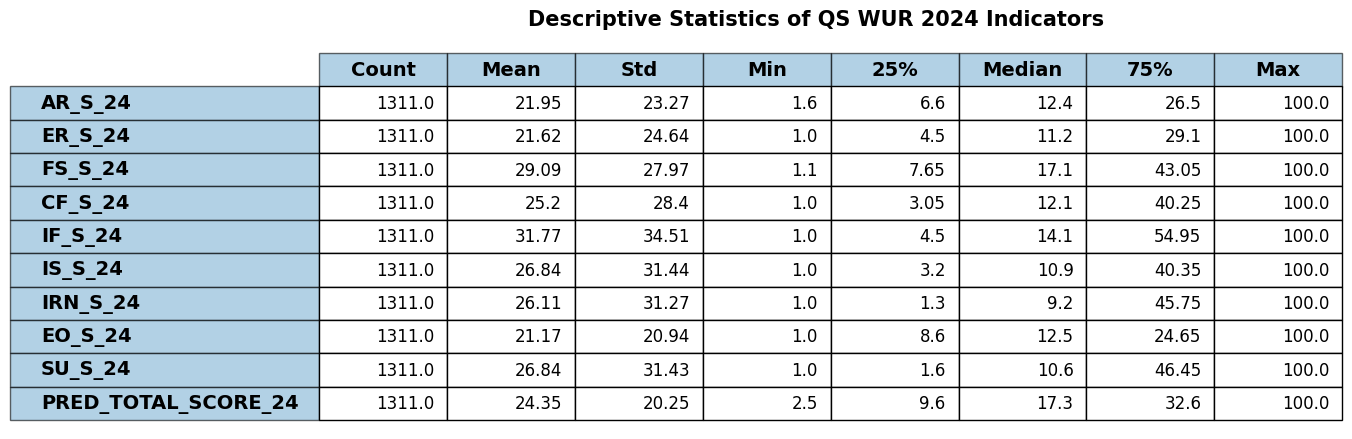

In [66]:
# Create PNG table
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

table = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    loc="center"
)

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.1, 2.0)

for (row, col), cell in table.get_celld().items():
    cell.set_text_props(verticalalignment="center")
    
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold", fontsize=14)
        cell.set_facecolor("#7FB3D5")
        cell.set_alpha(0.6)
        
# Add title
fig.suptitle(
    "Descriptive Statistics of QS WUR 2024 Indicators",
    fontsize=15,
    fontweight="bold",
    y=0.95
)

In [67]:
# Force rendering before saving
fig.canvas.draw()

# Export as PNG
fig.savefig(
    "outputs/descriptive_statistics_2024.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

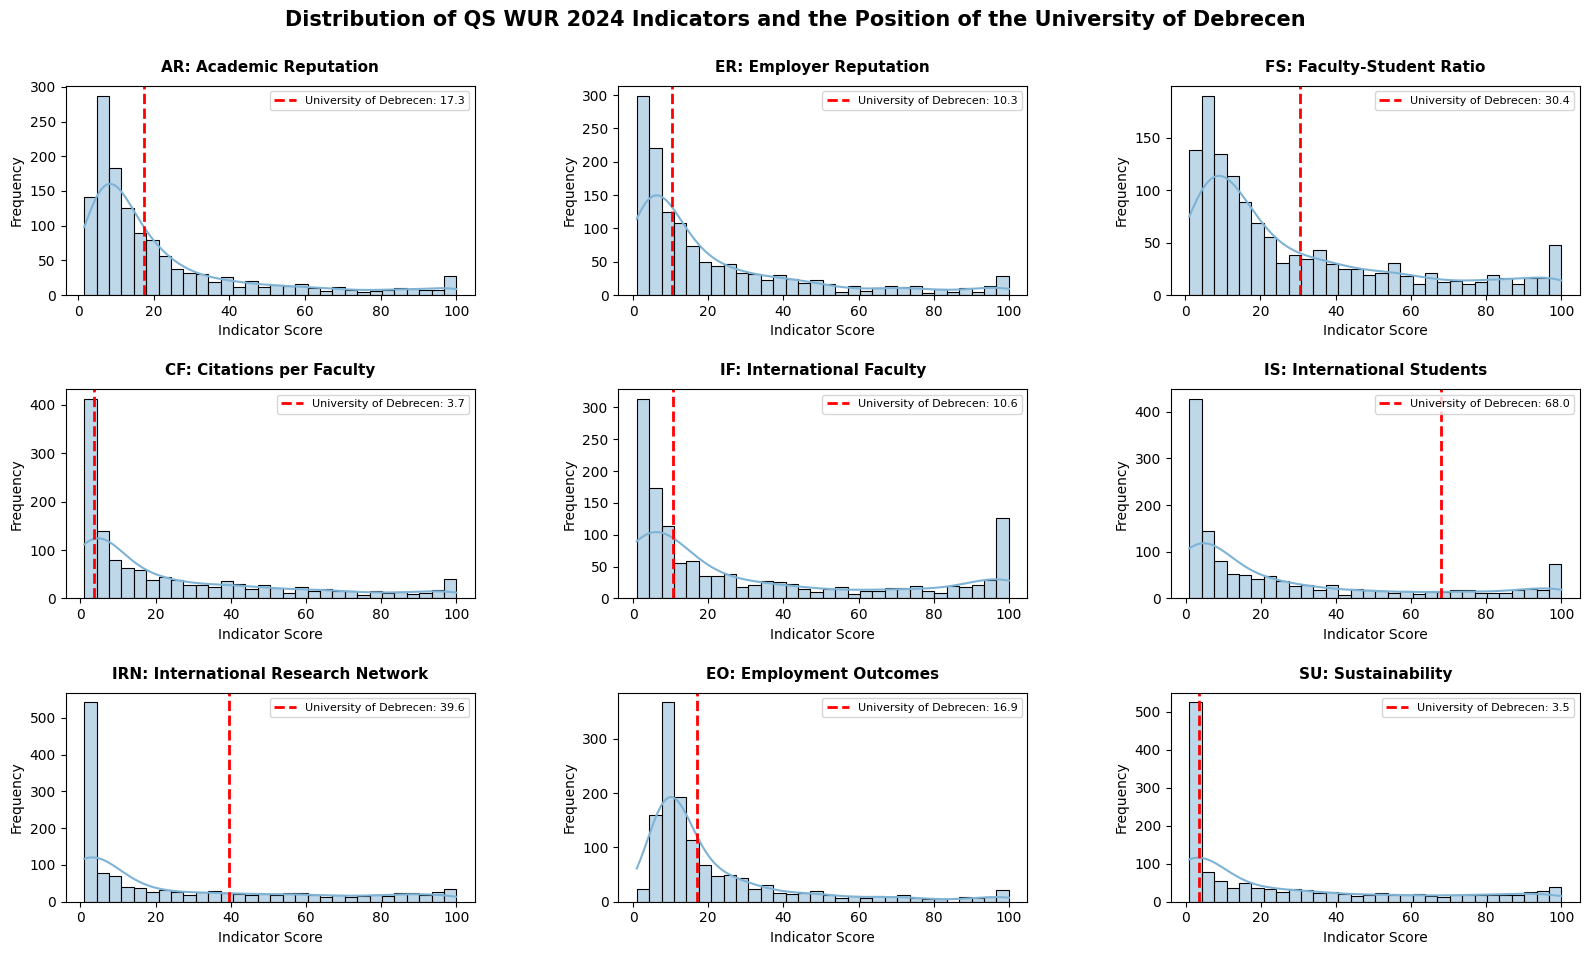

In [68]:
# Indicators to plot
indicators = [
    "AR_S_24", "ER_S_24", "FS_S_24", "CF_S_24",
    "IF_S_24", "IS_S_24", "IRN_S_24", "EO_S_24",
    "SU_S_24"
]

# Get University of Debrecen row
debrecen = df[df["UNI_24"].str.contains("Debrecen", case=False, na=False)]

# Create grid
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(indicators):
    ax = axes[i]
    
    # Histogram
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=ax,
        color="#7FB3D5"
    )
    
    # Mark University of Debrecen
    if not debrecen.empty:
        value = debrecen[col].iloc[0]
        ax.axvline(
            value,
            color="red",
            linewidth=2,
            linestyle="--",
            label=f"University of Debrecen: {value:.1f}"
        )
        ax.legend(fontsize=8)
    
    # Custom histogram titles
    titles = {
    "AR_S_24": "AR: Academic Reputation",
    "ER_S_24": "ER: Employer Reputation",
    "FS_S_24": "FS: Faculty-Student Ratio",
    "CF_S_24": "CF: Citations per Faculty",
    "IF_S_24": "IF: International Faculty",
    "IS_S_24": "IS: International Students",
    "IRN_S_24": "IRN: International Research Network",
    "EO_S_24": "EO: Employment Outcomes",
    "SU_S_24": "SU: Sustainability"
    }
    
    ax.set_title(
    titles[col],
    fontsize=11,
    fontweight="bold",
    pad=10
    )

    ax.set_xlabel("Indicator Score")
    ax.set_ylabel("Frequency")

# Remove unused subplot
for j in range(len(indicators), len(axes)):
    fig.delaxes(axes[j])

# Main title
fig.suptitle(
    "Distribution of QS WUR 2024 Indicators and the Position of the University of Debrecen",
    fontsize=15,
    fontweight="bold",
    y=0.95
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(
    wspace=0.35,
    hspace=0.45
)

# Save PNG
fig.savefig(
    "outputs/indicator_distributions_ud_2024.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

In [69]:
# Correlation matrix
corr_matrix = df[indicators].corr().round(2)
corr_matrix

,AR_S_24,ER_S_24,FS_S_24,CF_S_24,IF_S_24,IS_S_24,IRN_S_24,EO_S_24,SU_S_24
AR_S_24,1.00,0.83,0.37,0.55,0.40,0.38,0.69,0.71,0.72
ER_S_24,0.83,1.00,0.34,0.40,0.33,0.34,0.46,0.66,0.56
FS_S_24,0.37,0.34,1.00,0.12,0.18,0.24,0.18,0.29,0.19
CF_S_24,0.55,0.40,0.12,1.00,0.43,0.35,0.54,0.41,0.57
IF_S_24,0.40,0.33,0.18,0.43,1.00,0.71,0.43,0.35,0.48
IS_S_24,0.38,0.34,0.24,0.35,0.71,1.00,0.38,0.32,0.41
IRN_S_24,0.69,0.46,0.18,0.54,0.43,0.38,1.00,0.49,0.78
EO_S_24,0.71,0.66,0.29,0.41,0.35,0.32,0.49,1.00,0.59
SU_S_24,0.72,0.56,0.19,0.57,0.48,0.41,0.78,0.59,1.00


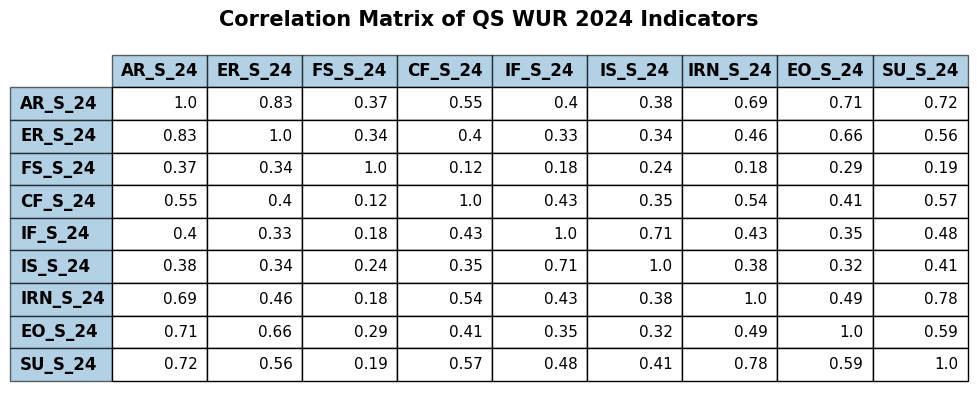

In [70]:
# Format labels
corr_matrix.index = corr_matrix.index.str.upper()
corr_matrix.columns = corr_matrix.columns.str.upper()

# Create table figure
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

table = ax.table(
    cellText=corr_matrix.values,
    rowLabels=corr_matrix.index,
    colLabels=corr_matrix.columns,
    loc="upper center"
)

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Style cells
for (row, col), cell in table.get_celld().items():
    cell.set_text_props(verticalalignment="center")
    
    # Headers + index
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold", fontsize=12)
        cell.set_facecolor("#7FB3D5")
        cell.set_alpha(0.6)

# Title
fig.suptitle(
    "Correlation Matrix of QS WUR 2024 Indicators",
    fontsize=15,
    fontweight="bold",
    y=0.97
)

plt.tight_layout()

# Save
fig.savefig(
    "outputs/correlation_matrix_wur2024.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

As I only see positive correlations, when creating the heatmap in the next step I choose the "Blues" Seaborn heatmap style.

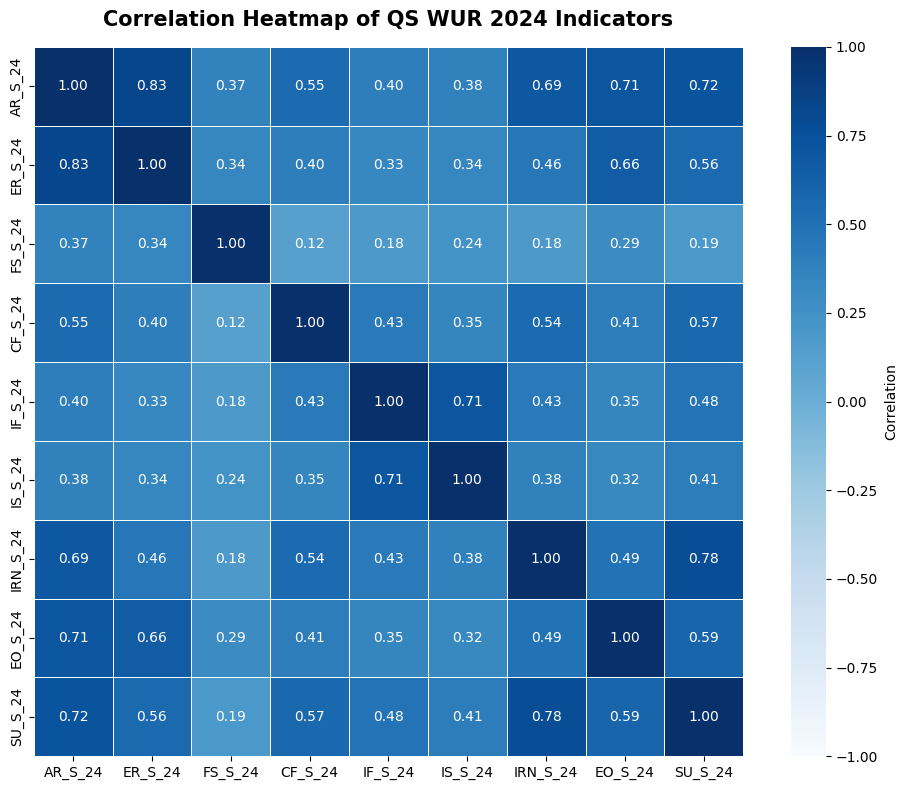

In [71]:
# Rename labels
corr_matrix.index = corr_matrix.index.str.upper()
corr_matrix.columns = corr_matrix.columns.str.upper()

# Create heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

# Title
plt.title(
    "Correlation Heatmap of QS WUR 2024 Indicators",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

# Save
plt.savefig(
    "outputs/correlation_heatmap_wur2024.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

Creating a network graph to further analyse relationships among indicators.

In [72]:
import networkx as nx
from itertools import combinations

networkx as nx is used to create, analyze, and visualize the network of indicators. It allows the construction of both directed and undirected graphs and provides efficient tools for network analysis.

itertools import combinations is used to generate all possible group combinations during the search for the optimal partition. This ensures that all feasible partitions were evaluated.

In [73]:
# For each indicator, find its 2 strongest correlations and create directed edges
edges = []

for indicator in indicators:

    # Remove self-correlation
    correlations = corr_matrix.loc[indicator].drop(indicator)

    # Find the two strongest correlations
    strongest = correlations.abs().sort_values(
        ascending=False
    ).head(2)

    # Create directed edges
    for target in strongest.index:
        weight = corr_matrix.loc[indicator, target]
        edges.append((indicator, target, weight))

print("Directed edges:")
for source, target, weight in edges:
    print(f"{source} → {target} ({weight:.3f})")

Directed edges:
AR_S_24 → ER_S_24 (0.830)
AR_S_24 → SU_S_24 (0.720)
ER_S_24 → AR_S_24 (0.830)
ER_S_24 → EO_S_24 (0.660)
FS_S_24 → AR_S_24 (0.370)
FS_S_24 → ER_S_24 (0.340)
CF_S_24 → SU_S_24 (0.570)
CF_S_24 → AR_S_24 (0.550)
IF_S_24 → IS_S_24 (0.710)
IF_S_24 → SU_S_24 (0.480)
IS_S_24 → IF_S_24 (0.710)
IS_S_24 → SU_S_24 (0.410)
IRN_S_24 → SU_S_24 (0.780)
IRN_S_24 → AR_S_24 (0.690)
EO_S_24 → AR_S_24 (0.710)
EO_S_24 → ER_S_24 (0.660)
SU_S_24 → IRN_S_24 (0.780)
SU_S_24 → AR_S_24 (0.720)


In [74]:
# Create directed graph
G = nx.DiGraph()

for source, target, weight in edges:
    G.add_edge(source, target, weight=weight)

In [75]:
# Convert to undirected graph for partitioning
UG = nx.Graph()

# Add all nodes
UG.add_nodes_from(G.nodes())

# Add an undirected edge if there is an edge in either direction
for u, v in G.edges():
    UG.add_edge(u, v)

In [76]:
# Search for optimal partition (3 groups of 3 nodes)
def cut_size(graph, partition):
    """
    Counts the number of edges connecting different groups.
    """
    node_to_group = {}

    for i, group in enumerate(partition):
        for node in group:
            node_to_group[node] = i

    cuts = 0

    for u, v in graph.edges():
        if node_to_group[u] != node_to_group[v]:
            cuts += 1

    return cuts

best_cut = np.inf
best_partition = None
seen_partitions = set()

for group1 in combinations(indicators, 3):

    remaining1 = set(indicators) - set(group1)

    for group2 in combinations(remaining1, 3):

        group3 = tuple(sorted(remaining1 - set(group2)))

        partition = (
            tuple(sorted(group1)),
            tuple(sorted(group2)),
            tuple(sorted(group3))
        )

        # Canonical representation to avoid duplicates
        canonical_partition = tuple(sorted(partition))

        if canonical_partition in seen_partitions:
            continue

        seen_partitions.add(canonical_partition)

        cuts = cut_size(UG, canonical_partition)

        if cuts < best_cut:
            best_cut = cuts
            best_partition = canonical_partition

# Store final result
final_partitions = [list(group) for group in best_partition]

print("\nOptimal partition:")
for i, group in enumerate(final_partitions):
    print(f"Group {i+1}: {group}")

print(f"\nBetween-group edges: {best_cut}")


Optimal partition:
Group 1: ['AR_S_24', 'CF_S_24', 'IRN_S_24']
Group 2: ['EO_S_24', 'ER_S_24', 'FS_S_24']
Group 3: ['IF_S_24', 'IS_S_24', 'SU_S_24']

Between-group edges: 6


In [77]:
# Map nodes to partition and assign colors
partition_map = {}

for i, group in enumerate(final_partitions):
    for node in group:
        partition_map[node] = i

color_dict = {
    0: "#DEEBF7",
    1: "#6BAED6",
    2: "#2171B5"
}

node_colors = [
    color_dict[partition_map[node]]
    for node in G.nodes()
]

The node positions are manually defined to enforce a hierarchical layout that reflects the directional flow of relationships in the network.
Indicators are arranged from source nodes on the left through intermediate hubs to outcome nodes on the right, preserving the logical structure of the directed graph.

In [78]:
#  Manual hierarchical layout based on the graph's flow
pos = {
    'IF_S_24': (0, 1),
    'IS_S_24': (0, -1),

    'SU_S_24': (2, 0),

    'CF_S_24': (4, 1),
    'IRN_S_24': (4, -1),

    'AR_S_24': (6, 0),

    'FS_S_24': (8, 1.5),
    'ER_S_24': (8, 0),
    'EO_S_24': (8, -1.5)
}

In [79]:
# Fallback if some labels are missing
if not all(node in pos for node in G.nodes()):
    print("\nSome nodes not found in manual layout.")
    print("Using spring layout instead.")
    pos = nx.spring_layout(G, seed=42)

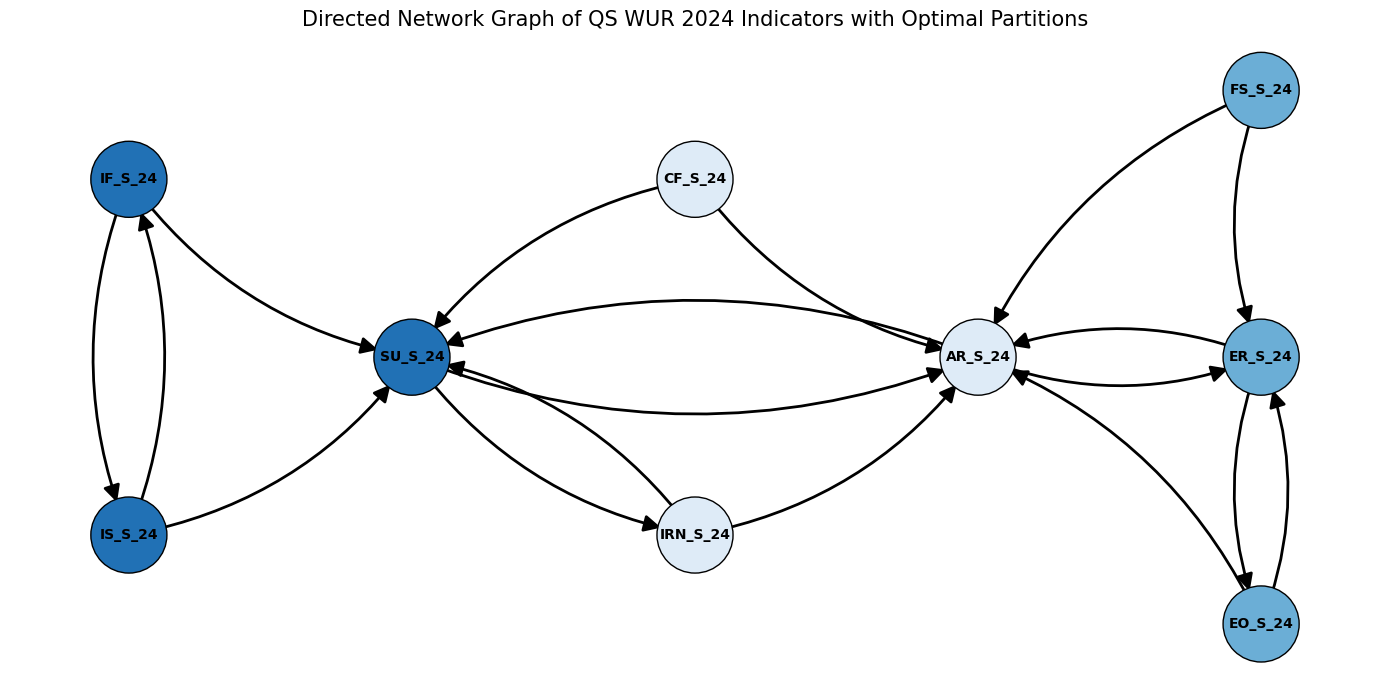

In [80]:
# Draw graph
plt.figure(figsize=(14, 7))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=3000,
    edgecolors='black'
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold'
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color='black',
    width=2,
    arrows=True,
    arrowsize=25,
    connectionstyle='arc3,rad=0.2',
    min_source_margin=20,
    min_target_margin=25
)

plt.title(
    "Directed Network Graph of QS WUR 2024 Indicators with Optimal Partitions",
    fontsize=15
)

plt.axis('off')
plt.tight_layout()
plt.savefig("outputs/network_graph_2024.png", dpi=300, bbox_inches='tight')
plt.show()

In [81]:
# Verify result
print("\nNode → Partition mapping")

for node in sorted(partition_map):
    print(f"{node}: Group {partition_map[node] + 1}")

print("\nFinal partitions:")
print(final_partitions)


Node → Partition mapping
AR_S_24: Group 1
CF_S_24: Group 1
EO_S_24: Group 2
ER_S_24: Group 2
FS_S_24: Group 2
IF_S_24: Group 3
IRN_S_24: Group 1
IS_S_24: Group 3
SU_S_24: Group 3

Final partitions:
[['AR_S_24', 'CF_S_24', 'IRN_S_24'], ['EO_S_24', 'ER_S_24', 'FS_S_24'], ['IF_S_24', 'IS_S_24', 'SU_S_24']]


Based on the previous steps, creating a function for printing correlation matrix and another for network graph development.

In [82]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def export_corr_matrix(file_path, year_suffix, output_folder="outputs"):

    os.makedirs(output_folder, exist_ok=True)

    # Load data
    df = pd.read_excel(file_path)

    base_indicators = [
        "AR_S_", "ER_S_", "FS_S_", "CF_S_",
        "IF_S_", "IS_S_", "IRN_S_", "EO_S_",
        "SU_S_"
    ]

    indicators = [b + year_suffix for b in base_indicators]

    corr_matrix = df[indicators].corr().round(2)

    # Format labels
    corr_matrix.index = corr_matrix.index.str.upper()
    corr_matrix.columns = corr_matrix.columns.str.upper()

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis("off")

    table = ax.table(
        cellText=corr_matrix.values,
        rowLabels=corr_matrix.index,
        colLabels=corr_matrix.columns,
        loc="upper center"
    )

    # Formatting
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)

    for (row, col), cell in table.get_celld().items():
        cell.set_text_props(verticalalignment="center")

        if row == 0 or col == -1:
            cell.set_text_props(weight="bold", fontsize=12)
            cell.set_facecolor("#7FB3D5")
            cell.set_alpha(0.6)

    # Title
    fig.suptitle(
        f"Correlation Matrix of QS WUR 20{year_suffix} Indicators",
        fontsize=15,
        fontweight="bold",
        y=0.97
    )

    plt.tight_layout()

    # Save output
    output_path = os.path.join(output_folder, f"correlation_matrix_wur20{year_suffix}_pipeline.png")

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close(fig)

    print(f"\nSaved correlation matrix to: {output_path}")

    return corr_matrix

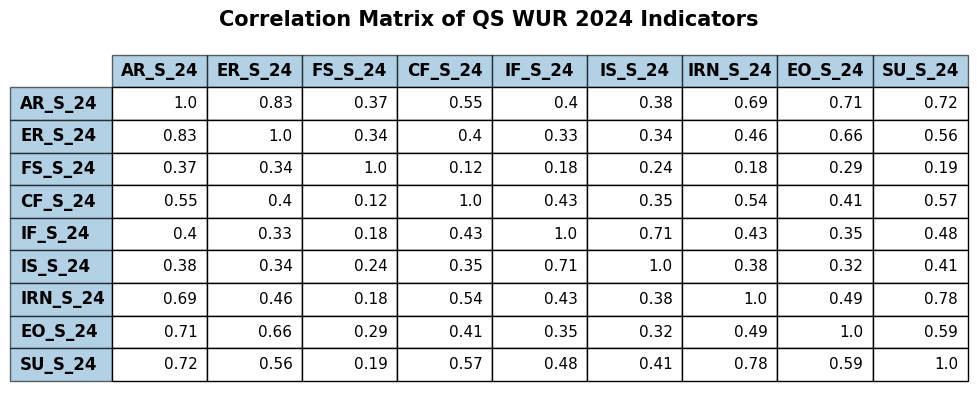


Saved correlation matrix to: outputs/correlation_matrix_wur2024_pipeline.png


,AR_S_24,ER_S_24,FS_S_24,CF_S_24,IF_S_24,IS_S_24,IRN_S_24,EO_S_24,SU_S_24
AR_S_24,1.00,0.83,0.37,0.55,0.40,0.38,0.69,0.71,0.72
ER_S_24,0.83,1.00,0.34,0.40,0.33,0.34,0.46,0.66,0.56
FS_S_24,0.37,0.34,1.00,0.12,0.18,0.24,0.18,0.29,0.19
CF_S_24,0.55,0.40,0.12,1.00,0.43,0.35,0.54,0.41,0.57
IF_S_24,0.40,0.33,0.18,0.43,1.00,0.71,0.43,0.35,0.48
IS_S_24,0.38,0.34,0.24,0.35,0.71,1.00,0.38,0.32,0.41
IRN_S_24,0.69,0.46,0.18,0.54,0.43,0.38,1.00,0.49,0.78
EO_S_24,0.71,0.66,0.29,0.41,0.35,0.32,0.49,1.00,0.59
SU_S_24,0.72,0.56,0.19,0.57,0.48,0.41,0.78,0.59,1.00


In [83]:
export_corr_matrix("wur_2024_final.xlsx", "24")

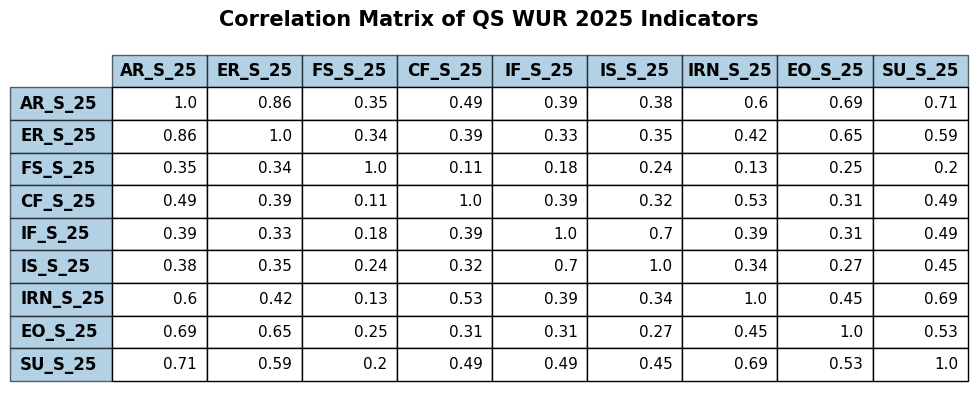


Saved correlation matrix to: outputs/correlation_matrix_wur2025_pipeline.png


,AR_S_25,ER_S_25,FS_S_25,CF_S_25,IF_S_25,IS_S_25,IRN_S_25,EO_S_25,SU_S_25
AR_S_25,1.00,0.86,0.35,0.49,0.39,0.38,0.60,0.69,0.71
ER_S_25,0.86,1.00,0.34,0.39,0.33,0.35,0.42,0.65,0.59
FS_S_25,0.35,0.34,1.00,0.11,0.18,0.24,0.13,0.25,0.20
CF_S_25,0.49,0.39,0.11,1.00,0.39,0.32,0.53,0.31,0.49
IF_S_25,0.39,0.33,0.18,0.39,1.00,0.70,0.39,0.31,0.49
IS_S_25,0.38,0.35,0.24,0.32,0.70,1.00,0.34,0.27,0.45
IRN_S_25,0.60,0.42,0.13,0.53,0.39,0.34,1.00,0.45,0.69
EO_S_25,0.69,0.65,0.25,0.31,0.31,0.27,0.45,1.00,0.53
SU_S_25,0.71,0.59,0.20,0.49,0.49,0.45,0.69,0.53,1.00


In [84]:
export_corr_matrix("wur_2025_final_pipeline.xlsx", "25")

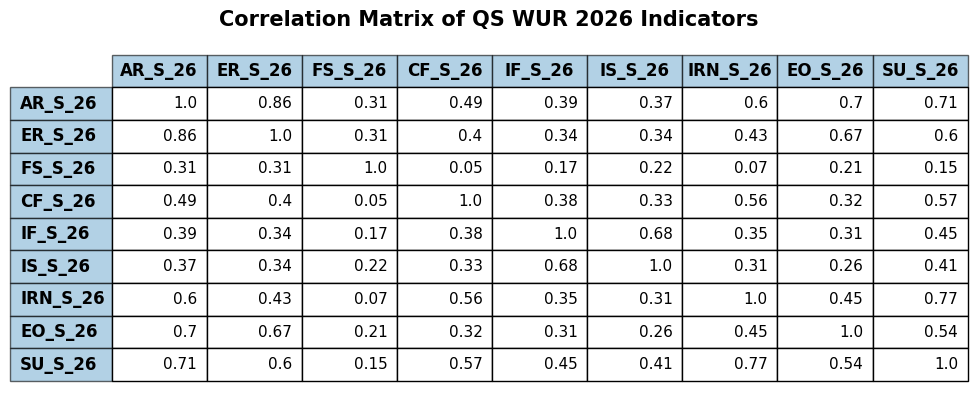


Saved correlation matrix to: outputs/correlation_matrix_wur2026_pipeline.png


,AR_S_26,ER_S_26,FS_S_26,CF_S_26,IF_S_26,IS_S_26,IRN_S_26,EO_S_26,SU_S_26
AR_S_26,1.00,0.86,0.31,0.49,0.39,0.37,0.60,0.70,0.71
ER_S_26,0.86,1.00,0.31,0.40,0.34,0.34,0.43,0.67,0.60
FS_S_26,0.31,0.31,1.00,0.05,0.17,0.22,0.07,0.21,0.15
CF_S_26,0.49,0.40,0.05,1.00,0.38,0.33,0.56,0.32,0.57
IF_S_26,0.39,0.34,0.17,0.38,1.00,0.68,0.35,0.31,0.45
IS_S_26,0.37,0.34,0.22,0.33,0.68,1.00,0.31,0.26,0.41
IRN_S_26,0.60,0.43,0.07,0.56,0.35,0.31,1.00,0.45,0.77
EO_S_26,0.70,0.67,0.21,0.32,0.31,0.26,0.45,1.00,0.54
SU_S_26,0.71,0.60,0.15,0.57,0.45,0.41,0.77,0.54,1.00


In [85]:
export_corr_matrix("wur_2026_final_pipeline.xlsx", "26")

In [86]:
def build_network(file_path, year_suffix, pos_common, output_folder="outputs", title=None):

    os.makedirs(output_folder, exist_ok=True)

    if title is None:
        title = f"Directed Network Graph of QS WUR 20{year_suffix} Indicators"

    # Load data
    df = pd.read_excel(file_path)

    # Indicators
    base_indicators = [
        "AR_S_", "ER_S_", "FS_S_", "CF_S_",
        "IF_S_", "IS_S_", "IRN_S_", "EO_S_",
        "SU_S_"
    ]

    indicators = [b + year_suffix for b in base_indicators]

    # Build edges (top 2 correlations per node)
    edges = []

    for indicator in indicators:

        correlations = df[indicators].corr()[indicator].drop(indicator)

        strongest = correlations.abs().sort_values(ascending=False).head(2)

        for target in strongest.index:
            weight = df[indicators].corr().loc[indicator, target]
            edges.append((indicator, target, weight))

    # Directed graph
    G = nx.DiGraph()
    G.add_weighted_edges_from(edges)

    # Undirected graph for partitioning
    UG = nx.Graph()
    UG.add_nodes_from(G.nodes())
    UG.add_edges_from(G.edges())

    # Partition optimization
    def cut_size(graph, partition):
        node_map = {}

        for i, group in enumerate(partition):
            for node in group:
                node_map[node] = i

        cuts = 0
        for u, v in graph.edges():
            if node_map[u] != node_map[v]:
                cuts += 1

        return cuts

    best_cut = np.inf
    best_partition = None
    seen = set()

    for g1 in combinations(indicators, 3):
        remaining1 = set(indicators) - set(g1)

        for g2 in combinations(remaining1, 3):
            g3 = tuple(sorted(remaining1 - set(g2)))

            partition = tuple(sorted([
                tuple(sorted(g1)),
                tuple(sorted(g2)),
                tuple(sorted(g3))
            ]))

            if partition in seen:
                continue
            seen.add(partition)

            cuts = cut_size(UG, partition)

            if cuts < best_cut:
                best_cut = cuts
                best_partition = partition

    final_partitions = [list(g) for g in best_partition]

    # Colors
    partition_map = {}

    for i, group in enumerate(final_partitions):
        for node in group:
            partition_map[node] = i

    color_dict = {
        0: "#DEEBF7",
        1: "#6BAED6",
        2: "#2171B5"
    }

    node_colors = [color_dict[partition_map[n]] for n in G.nodes()]

    # Layout (fixed across years)
    pos = {}

    for key, coord in pos_common.items():
        full_node = f"{key}_S_{year_suffix}"
        pos[full_node] = coord

    if not all(node in pos for node in G.nodes()):
        pos = nx.spring_layout(G, seed=42)

    # Plot
    plt.figure(figsize=(14, 7))

    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=3000,
        edgecolors='black'
    )

    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    nx.draw_networkx_edges(
        G, pos,
        edge_color='black',
        width=2,
        arrows=True,
        arrowsize=25,
        connectionstyle='arc3,rad=0.2',
        min_source_margin=20,
        min_target_margin=25
    )

    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.tight_layout()

    output_path = os.path.join(output_folder, f"network_graph_20{year_suffix}_pipeline.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

    plt.show()

    # Output only partitions (no correlation matrix)
    print("\nNode → Partition mapping")
    for node in sorted(partition_map):
        print(f"{node}: Group {partition_map[node] + 1}")

    print("\nFinal partitions:")
    print(final_partitions)

    print(f"\nSaved to: {output_path}")

    return {
        "G": G,
        "UG": UG,
        "final_partitions": final_partitions,
        "partition_map": partition_map,
        "edges": edges
    }

In [87]:
pos_common = {
    "IF": (0, 1),
    "IS": (0, -1),
    "SU": (2, 0),
    "CF": (4, 1),
    "IRN": (4, -1),
    "AR": (6, 0),
    "FS": (8, 1.5),
    "ER": (8, 0),
    "EO": (8, -1.5)
}

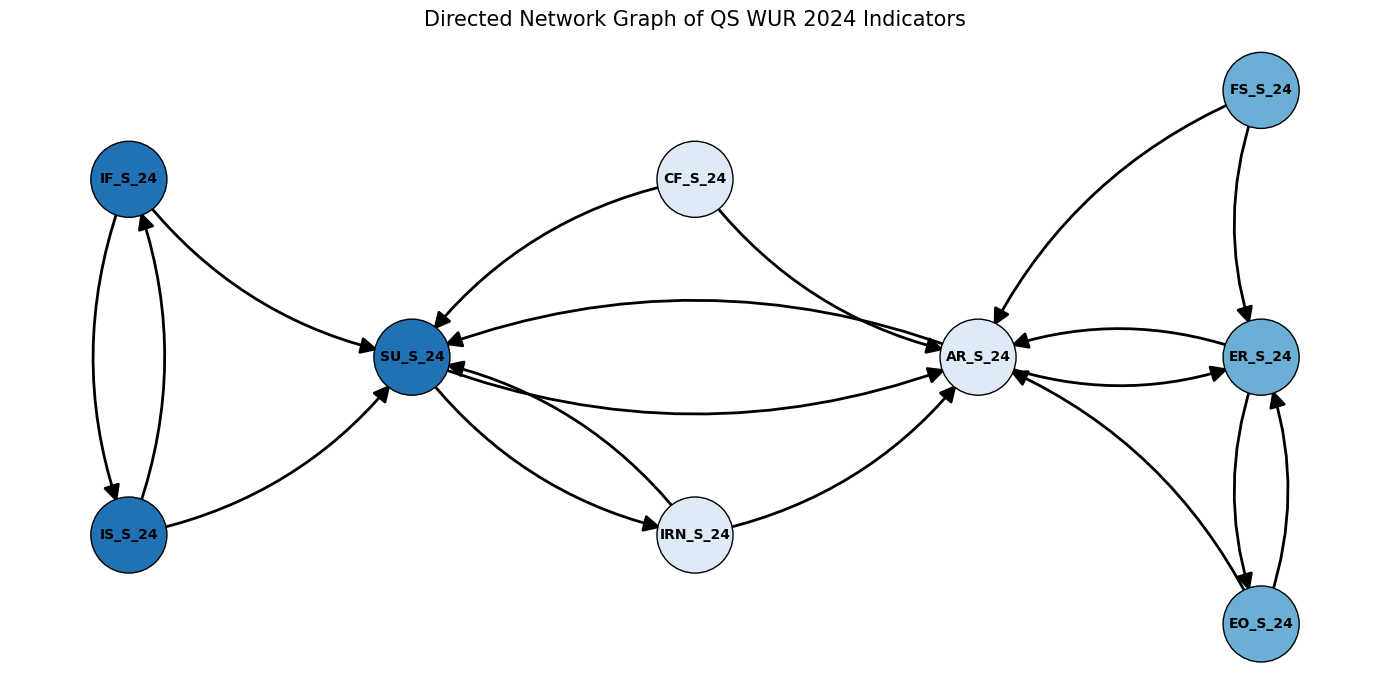


Node → Partition mapping
AR_S_24: Group 1
CF_S_24: Group 1
EO_S_24: Group 2
ER_S_24: Group 2
FS_S_24: Group 2
IF_S_24: Group 3
IRN_S_24: Group 1
IS_S_24: Group 3
SU_S_24: Group 3

Final partitions:
[['AR_S_24', 'CF_S_24', 'IRN_S_24'], ['EO_S_24', 'ER_S_24', 'FS_S_24'], ['IF_S_24', 'IS_S_24', 'SU_S_24']]

Saved to: outputs/network_graph_2024_pipeline.png


{'G': <networkx.classes.digraph.DiGraph at 0x7fd8a19559d0>,
 'UG': <networkx.classes.graph.Graph at 0x7fd89a96df70>,
 'final_partitions': [['AR_S_24', 'CF_S_24', 'IRN_S_24'],
  ['EO_S_24', 'ER_S_24', 'FS_S_24'],
  ['IF_S_24', 'IS_S_24', 'SU_S_24']],
 'partition_map': {'AR_S_24': 0,
  'CF_S_24': 0,
  'IRN_S_24': 0,
  'EO_S_24': 1,
  'ER_S_24': 1,
  'FS_S_24': 1,
  'IF_S_24': 2,
  'IS_S_24': 2,
  'SU_S_24': 2},
 'edges': [('AR_S_24', 'ER_S_24', np.float64(0.8320530888795775)),
  ('AR_S_24', 'SU_S_24', np.float64(0.722366956526003)),
  ('ER_S_24', 'AR_S_24', np.float64(0.8320530888795775)),
  ('ER_S_24', 'EO_S_24', np.float64(0.659313407948912)),
  ('FS_S_24', 'AR_S_24', np.float64(0.37060140583034384)),
  ('FS_S_24', 'ER_S_24', np.float64(0.34409967314389167)),
  ('CF_S_24', 'SU_S_24', np.float64(0.5663066482459267)),
  ('CF_S_24', 'AR_S_24', np.float64(0.5491560909434039)),
  ('IF_S_24', 'IS_S_24', np.float64(0.7070658052159546)),
  ('IF_S_24', 'SU_S_24', np.float64(0.48347701970917967)

In [88]:
build_network("wur_2024_final.xlsx", "24", pos_common)

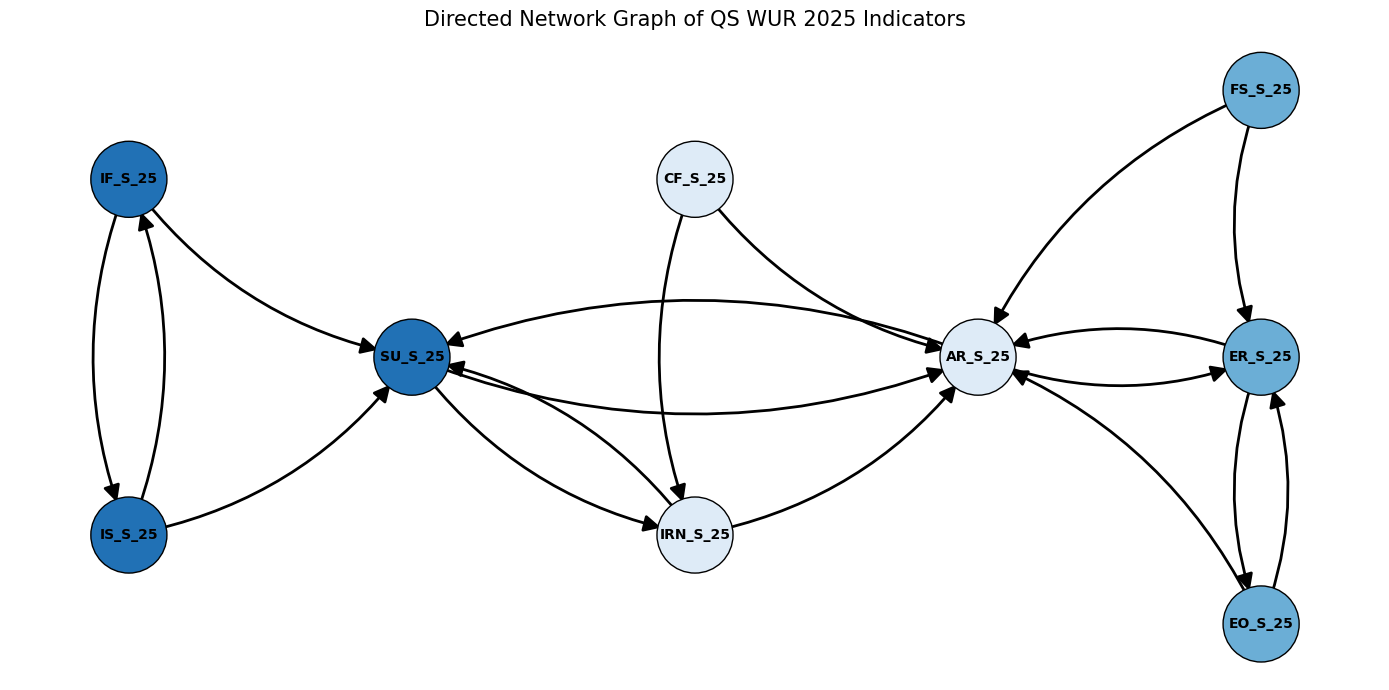


Node → Partition mapping
AR_S_25: Group 1
CF_S_25: Group 1
EO_S_25: Group 2
ER_S_25: Group 2
FS_S_25: Group 2
IF_S_25: Group 3
IRN_S_25: Group 1
IS_S_25: Group 3
SU_S_25: Group 3

Final partitions:
[['AR_S_25', 'CF_S_25', 'IRN_S_25'], ['EO_S_25', 'ER_S_25', 'FS_S_25'], ['IF_S_25', 'IS_S_25', 'SU_S_25']]

Saved to: outputs/network_graph_2025_pipeline.png


{'G': <networkx.classes.digraph.DiGraph at 0x7fd89a1980d0>,
 'UG': <networkx.classes.graph.Graph at 0x7fd89a96df40>,
 'final_partitions': [['AR_S_25', 'CF_S_25', 'IRN_S_25'],
  ['EO_S_25', 'ER_S_25', 'FS_S_25'],
  ['IF_S_25', 'IS_S_25', 'SU_S_25']],
 'partition_map': {'AR_S_25': 0,
  'CF_S_25': 0,
  'IRN_S_25': 0,
  'EO_S_25': 1,
  'ER_S_25': 1,
  'FS_S_25': 1,
  'IF_S_25': 2,
  'IS_S_25': 2,
  'SU_S_25': 2},
 'edges': [('AR_S_25', 'ER_S_25', np.float64(0.8556573590680283)),
  ('AR_S_25', 'SU_S_25', np.float64(0.7089559023243718)),
  ('ER_S_25', 'AR_S_25', np.float64(0.8556573590680283)),
  ('ER_S_25', 'EO_S_25', np.float64(0.6539871662463449)),
  ('FS_S_25', 'AR_S_25', np.float64(0.353774816167489)),
  ('FS_S_25', 'ER_S_25', np.float64(0.3404392997798478)),
  ('CF_S_25', 'IRN_S_25', np.float64(0.5265478229859131)),
  ('CF_S_25', 'AR_S_25', np.float64(0.49439254615558187)),
  ('IF_S_25', 'IS_S_25', np.float64(0.6998752577570705)),
  ('IF_S_25', 'SU_S_25', np.float64(0.49455030681438844

In [89]:
build_network("wur_2025_final_pipeline.xlsx", "25", pos_common)

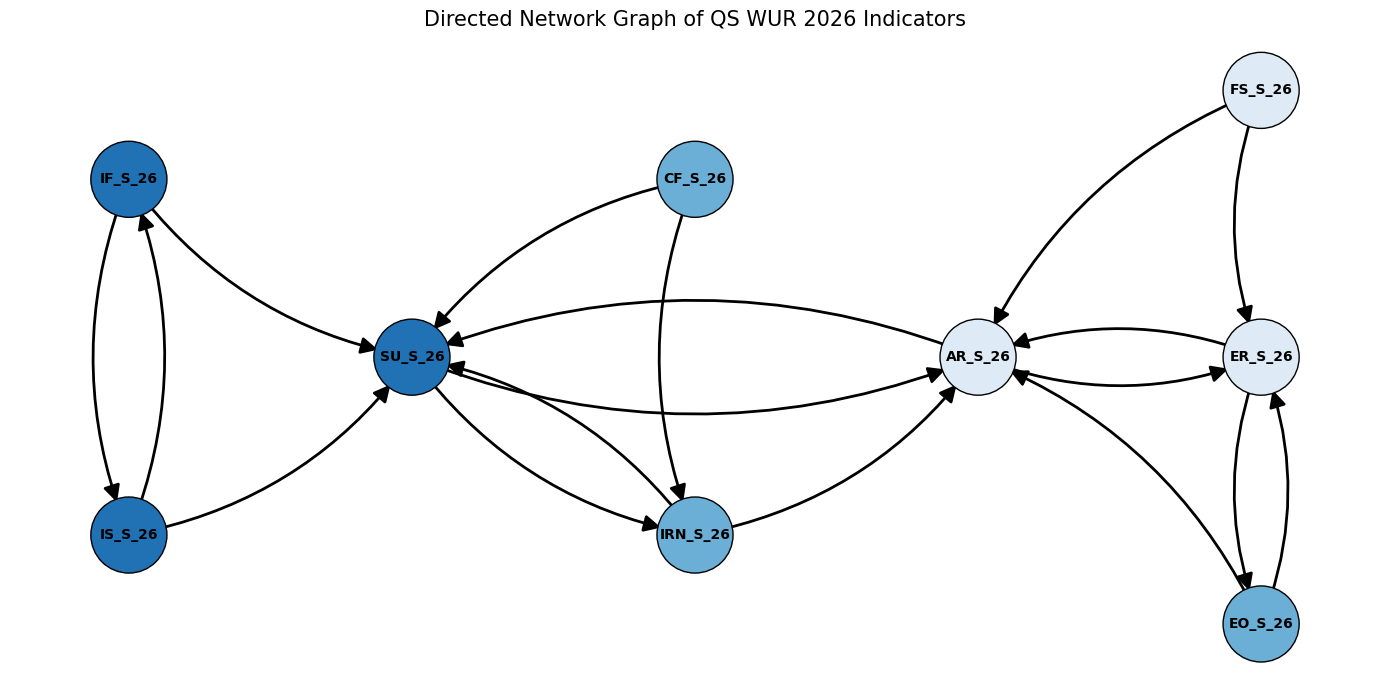


Node → Partition mapping
AR_S_26: Group 1
CF_S_26: Group 2
EO_S_26: Group 2
ER_S_26: Group 1
FS_S_26: Group 1
IF_S_26: Group 3
IRN_S_26: Group 2
IS_S_26: Group 3
SU_S_26: Group 3

Final partitions:
[['AR_S_26', 'ER_S_26', 'FS_S_26'], ['CF_S_26', 'EO_S_26', 'IRN_S_26'], ['IF_S_26', 'IS_S_26', 'SU_S_26']]

Saved to: outputs/network_graph_2026_pipeline.png


{'G': <networkx.classes.digraph.DiGraph at 0x7fd89accec10>,
 'UG': <networkx.classes.graph.Graph at 0x7fd89a9f5e50>,
 'final_partitions': [['AR_S_26', 'ER_S_26', 'FS_S_26'],
  ['CF_S_26', 'EO_S_26', 'IRN_S_26'],
  ['IF_S_26', 'IS_S_26', 'SU_S_26']],
 'partition_map': {'AR_S_26': 0,
  'ER_S_26': 0,
  'FS_S_26': 0,
  'CF_S_26': 1,
  'EO_S_26': 1,
  'IRN_S_26': 1,
  'IF_S_26': 2,
  'IS_S_26': 2,
  'SU_S_26': 2},
 'edges': [('AR_S_26', 'ER_S_26', np.float64(0.860600826160711)),
  ('AR_S_26', 'SU_S_26', np.float64(0.7118283192630024)),
  ('ER_S_26', 'AR_S_26', np.float64(0.860600826160711)),
  ('ER_S_26', 'EO_S_26', np.float64(0.6731043389960409)),
  ('FS_S_26', 'AR_S_26', np.float64(0.3101331546705804)),
  ('FS_S_26', 'ER_S_26', np.float64(0.3066375913587479)),
  ('CF_S_26', 'SU_S_26', np.float64(0.565068127053022)),
  ('CF_S_26', 'IRN_S_26', np.float64(0.5630843722260261)),
  ('IF_S_26', 'IS_S_26', np.float64(0.6779835342497621)),
  ('IF_S_26', 'SU_S_26', np.float64(0.44928261848101786)),

In [90]:
build_network("wur_2026_final_pipeline.xlsx", "26", pos_common)

A Shapley value decomposition of the model's explained variance (R square) is performed to quantify the relative contribution of each indicator to the overall predictive performance of the model.

In [91]:
# Calculate R square for every possible predictor set

import pandas as pd
import numpy as np

from itertools import combinations
from math import factorial

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Select predictors and target
predictors = ["AR_S_24", "ER_S_24", "FS_S_24", "CF_S_24", "IF_S_24", "IS_S_24", "IRN_S_24", "EO_S_24", "SU_S_24"]

target = "PRED_TOTAL_SCORE_24"

X = wur_2024_final[predictors]
y = wur_2024_final[target]

# Calculate R square of all subsets

subset_r2 = {}

# Empty model
subset_r2[frozenset()] = 0

for k in range(1, len(predictors) + 1):

    for subset in combinations(predictors, k):

        model = LinearRegression()

        model.fit(X[list(subset)], y)

        prediction = model.predict(X[list(subset)])

        subset_r2[frozenset(subset)] = r2_score(y, prediction)

print(f"Calculated R square for {len(subset_r2)} subsets.")

Calculated R square for 512 subsets.


In [92]:
# Calculate Shapley importance values

n = len(predictors)

shapley = {}

for feature in predictors:

    value = 0

    others = [p for p in predictors if p != feature]

    for k in range(len(others) + 1):

        for subset in combinations(others, k):

            subset_fs = frozenset(subset)
            subset_plus_fs = subset_fs | {feature}

            # SAFE lookup (prevents KeyError in edge cases)
            r2_without = subset_r2.get(subset_fs, 0)
            r2_with = subset_r2.get(subset_plus_fs, 0)

            marginal = r2_with - r2_without

            weight = (
                factorial(len(subset))
                * factorial(n - len(subset) - 1)
                / factorial(n)
            )

            value += weight * marginal

    shapley[feature] = value

importance = pd.DataFrame({
    "Indicator": predictors,
    "Shapley": [shapley[p] for p in predictors]
})

print("Full model R square :", subset_r2[frozenset(predictors)])
print("Sum Shapley   :", importance["Shapley"].sum())

Full model R square : 1.0
Sum Shapley   : 1.0


In [93]:
# Relative importance values

groups = {
    "Research and Discovery": ["AR_S_24", "CF_S_24"],
    "Empoyability": ["ER_S_24", "EO_S_24"],
    "Learning Experience": ["FS_S_24"],
    "Global Engagement": ["IS_S_24", "IRN_S_24", "IF_S_24"],
    "Sustainability": ["SU_S_24"]
}

group_lookup = {}

for group, variables in groups.items():
    for var in variables:
        group_lookup[var] = group

importance["Group"] = importance["Indicator"].map(group_lookup)

# Check
importance["Group"] = importance["Group"].fillna("Unknown")

# Total importance

importance["Total Importance"] = (
    importance["Shapley"] / importance["Shapley"].sum()
)

importance["Total Importance (%)"] = importance["Total Importance"] * 100

# Within-group importance

group_sums = importance.groupby("Group")["Shapley"].transform("sum")

importance["Within Group"] = importance["Shapley"] / group_sums
importance["Within Group (%)"] = importance["Within Group"] * 100

importance = importance.sort_values("Total Importance", ascending=False)

In [94]:
# Validation & Export

print("\nTotal importance table:\n")

print(
    importance[
        ["Indicator", "Group", "Total Importance (%)", "Within Group (%)"]
    ]
)

print("\nChecks:")

print("Overall sum (expected to be around 1):",
      importance["Total Importance"].sum())

print("\nGroup sums (expected to be around 1 each):")
print(importance.groupby("Group")["Within Group"].sum())

output_file = "QS_Shapley_Importance_2024.xlsx"

importance.to_excel("outputs/QS_Shapley_Importance_2024.xlsx", index=False)

print(f"\nSaved file: {output_file}")


Total importance table:

  Indicator                   Group  Total Importance (%)  Within Group (%)
0   AR_S_24  Research and Discovery             21.562598         59.675667
1   ER_S_24            Empoyability             15.042732         60.482732
3   CF_S_24  Research and Discovery             14.570384         40.324333
8   SU_S_24          Sustainability             11.906771        100.000000
6  IRN_S_24       Global Engagement             10.301508         46.976259
7   EO_S_24            Empoyability              9.828387         39.517268
4   IF_S_24       Global Engagement              6.162590         28.102239
5   IS_S_24       Global Engagement              5.465081         24.921502
2   FS_S_24     Learning Experience              5.159949        100.000000

Checks:
Overall sum (expected to be around 1): 1.0

Group sums (expected to be around 1 each):
Group
Empoyability              1.0
Global Engagement         1.0
Learning Experience       1.0
Research and Discovery

The Shapley decomposition results indicate that the explanatory power of the model is distributed unevenly across the selected indicators. The most influential variable is AR_S_24 (Reputation), contributing approximately 21.6% of the total importance. This is followed by ER_S_24 (Reputation) with 15.0%, suggesting that reputation-related measures jointly represent the dominant dimension in explaining the predicted outcome.

Research-related indicators show a more moderate contribution overall. CF_S_24 accounts for 14.6%, making it one of the stronger individual predictors in the model, whereas IF_S_24 contributes a relatively smaller share of 6.2%. This difference indicates that the research dimension is not homogeneous in its explanatory strength.

Within the international dimension, IRN_S_24 has a more substantial effect (10.3%) compared to IS_S_24 (5.5%), suggesting that international performance is primarily driven by one component rather than being evenly distributed across indicators.

Sustainability-related variables also play a meaningful role in the model. SU_S_24 contributes 11.9%, while EO_S_24 accounts for 9.8%, positioning this group as a mid-level contributor to the overall explanation of the target variable.

The group-level results confirm internal consistency, with within-group importance values summing to 1 across all categories. The decomposition also verifies that the full model R square is fully attributed across predictors without residual loss, supporting the robustness of the Shapley-based interpretation.

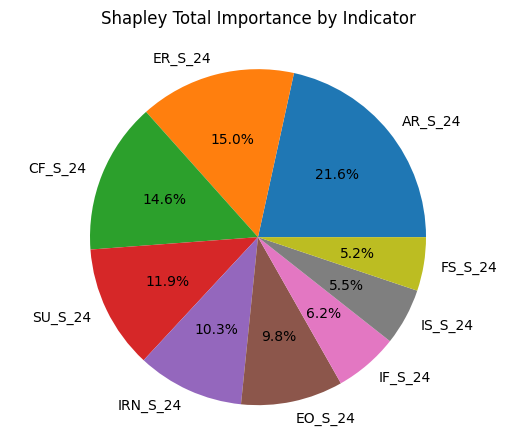

In [95]:
# Total importance (by indicator)

importance_sorted = importance.sort_values("Total Importance (%)")

plt.figure()

plt.pie(
    importance["Total Importance (%)"],
    labels=importance["Indicator"],
    autopct="%1.1f%%"
)

plt.title("Shapley Total Importance by Indicator\n")
plt.axis("equal")

plt.show()

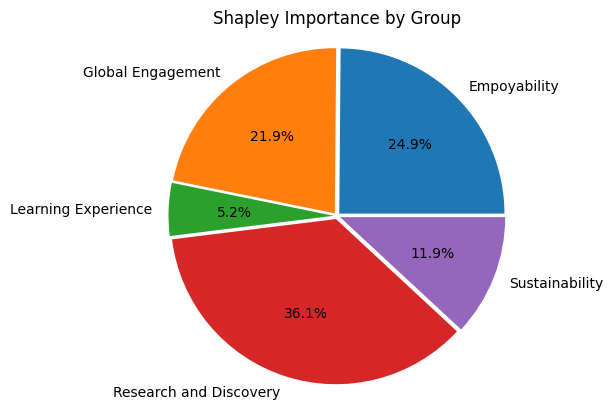

In [96]:
# Group-level importance

# Aggregating by group
group_importance = importance.groupby("Group")["Shapley"].sum()
group_importance = group_importance / group_importance.sum() * 100

plt.figure()

plt.pie(
    group_importance,
    labels=group_importance.index,
    autopct="%1.1f%%",
    explode=[0.02]*len(group_importance)
)

plt.title("Shapley Importance by Group")
plt.axis("equal")

plt.show()

In [97]:
# Normalizing indicator-level importance

importance = importance.copy()

importance["Norm Importance"] = (
    importance["Shapley"] / importance["Shapley"].sum()
) * 100


In [98]:
# Recalculatin group-level from normalized values

group_order = (
    importance.groupby("Group", observed=True)["Norm Importance"]
    .sum()
    .sort_values(ascending=False)
    .index
)

importance["Group"] = pd.Categorical(
    importance["Group"],
    categories=group_order,
    ordered=True
)

importance = importance.sort_values(["Group", "Norm Importance"], ascending=[True, False])

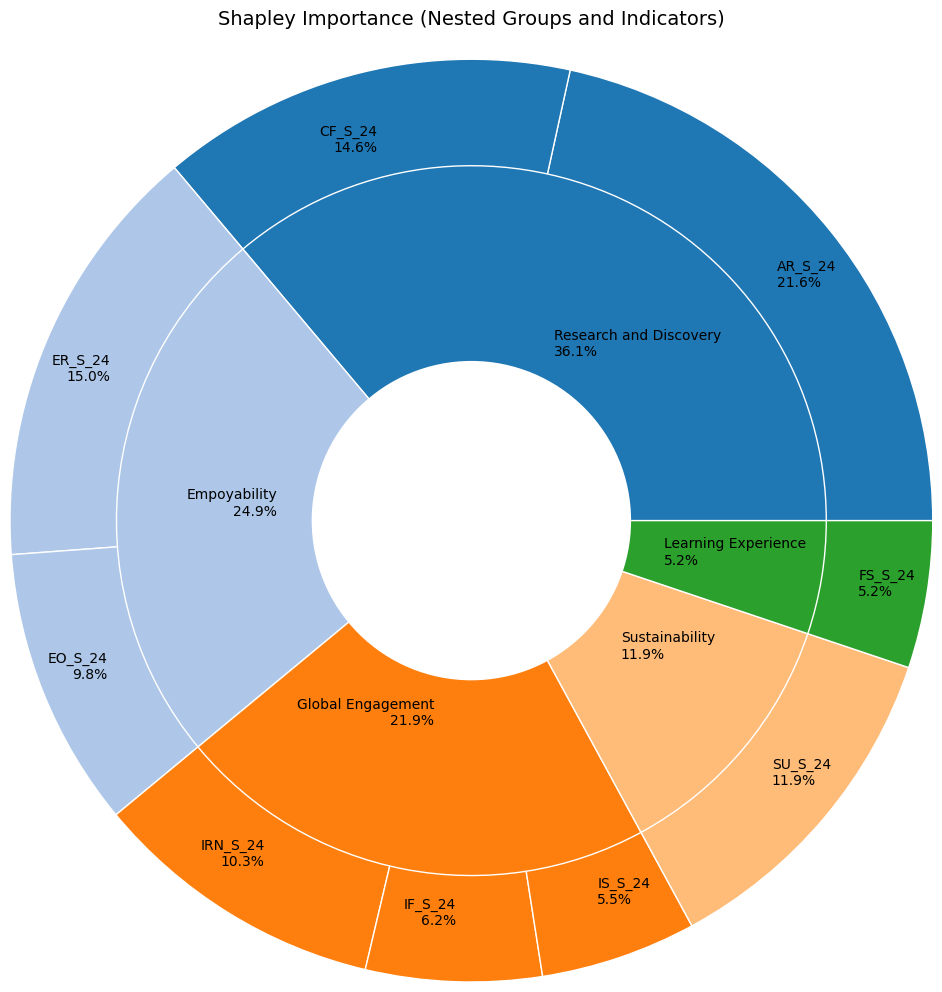

In [99]:
# Inner ring
group_importance = (
    importance.groupby("Group", observed=True)["Norm Importance"]
    .sum()
    .reindex(group_order)
)

inner_labels_raw = group_importance.index.tolist()

inner_labels = [
    f"{g}\n{v:.1f}%"
    for g, v in zip(group_importance.index, group_importance.values)
]

inner_sizes = group_importance.values

#outer ring
outer_labels = [
    f"{ind}\n{val:.1f}%"
    for ind, val in zip(importance["Indicator"], importance["Norm Importance"])
]

outer_sizes = importance["Norm Importance"].tolist()
outer_groups = importance["Group"].tolist()


cmap = plt.get_cmap("tab20")

group_colors = {g: cmap(i % 20) for i, g in enumerate(inner_labels_raw)}
outer_colors = [group_colors[g] for g in outer_groups]
inner_colors = [group_colors[g] for g in inner_labels_raw]


# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Outer
ax.pie(
    outer_sizes,
    radius=1.3,
    labels=outer_labels,
    labeldistance=0.85,
    colors=outer_colors,
    wedgeprops=dict(width=0.35, edgecolor="white")
)

# Inner
ax.pie(
    inner_sizes,
    radius=1.0,
    labels=inner_labels,
    labeldistance=0.55,
    colors=inner_colors,
    wedgeprops=dict(width=0.65, edgecolor="white")
)

# Centre
centre_circle = plt.Circle((0, 0), 0.45, fc="white")
ax.add_artist(centre_circle)

ax.set_title("Shapley Importance (Nested Groups and Indicators)\n\n", fontsize=14)

plt.tight_layout()

plt.savefig("outputs/shapley_importance.png", dpi=300, bbox_inches="tight")

plt.show()

To enable the consistent application of the Shapley value decomposition across multiple datasets, a reusable function was developed. The function automates the complete analysis workflow, including the estimation of regression models, calculation of Shapley values based on the R² decomposition, normalization of indicator importance, and generation of standardized output tables. This approach ensures a reproducible and efficient methodology for comparing indicator importance across different datasets.

In [100]:
import os
import pandas as pd
import numpy as np
from itertools import combinations
from math import factorial
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from IPython.display import display


def run_shapley_pipeline(
    df,
    year,
    suffix="24",
    output_dir="outputs",
    save_excel=True
):
    # Automating column setup
    predictors = [
        f"AR_S_{suffix}", f"ER_S_{suffix}", f"FS_S_{suffix}",
        f"CF_S_{suffix}", f"IF_S_{suffix}", f"IS_S_{suffix}",
        f"IRN_S_{suffix}", f"EO_S_{suffix}", f"SU_S_{suffix}"
    ]

    target = f"PRED_TOTAL_SCORE_{suffix}"

    groups = {
        "Research and Discovery": [f"AR_S_{suffix}", f"CF_S_{suffix}"],
        "Empoyability": [f"ER_S_{suffix}", f"EO_S_{suffix}"],
        "Learning Experience": [f"FS_S_{suffix}"],
        "Global Engagement": [f"IS_S_{suffix}", f"IRN_S_{suffix}", f"IF_S_{suffix}"],
        "Sustainability": [f"SU_S_{suffix}"]
    }

    X = df[predictors]
    y = df[target]

    # R square subsets
    subset_r2 = {frozenset(): 0}

    for k in range(1, len(predictors) + 1):
        for subset in combinations(predictors, k):
            model = LinearRegression()
            model.fit(X[list(subset)], y)
            pred = model.predict(X[list(subset)])
            subset_r2[frozenset(subset)] = r2_score(y, pred)

    print(f"Calculated R square for {len(subset_r2)} subsets.")

    # Shapley
    n = len(predictors)
    shapley = {}

    for feature in predictors:
        value = 0
        others = [p for p in predictors if p != feature]

        for k in range(len(others) + 1):
            for subset in combinations(others, k):

                subset_fs = frozenset(subset)
                subset_plus_fs = subset_fs | {feature}

                r2_without = subset_r2.get(subset_fs, 0)
                r2_with = subset_r2.get(subset_plus_fs, 0)

                marginal = r2_with - r2_without

                weight = (
                    factorial(len(subset))
                    * factorial(n - len(subset) - 1)
                    / factorial(n)
                )

                value += weight * marginal

        shapley[feature] = value

    importance = pd.DataFrame({
        "Indicator": predictors,
        "Shapley": [shapley[p] for p in predictors]
    })

    # Grouping
    group_lookup = {
        var: group
        for group, vars_list in groups.items()
        for var in vars_list
    }

    importance["Group"] = importance["Indicator"].map(group_lookup).fillna("Unknown")

    # Importance
    importance["Total Importance"] = importance["Shapley"] / importance["Shapley"].sum()
    importance["Total Importance (%)"] = importance["Total Importance"] * 100

    group_sums = importance.groupby("Group")["Shapley"].transform("sum")
    importance["Within Group"] = importance["Shapley"] / group_sums
    importance["Within Group (%)"] = importance["Within Group"] * 100

    importance = importance.sort_values("Total Importance", ascending=False)

    # Validation
    print("\nChecks:")
    print("Overall sum:", importance["Total Importance"].sum())
    print("\nGroup sums:")
    print(importance.groupby("Group")["Within Group"].sum())

    # Dispaly
    print("\nTotal importance table:\n")

    table = importance[
        ["Indicator", "Group", "Total Importance (%)", "Within Group (%)"]
    ]

    display(table)

    # Save
    if save_excel:
        os.makedirs(output_dir, exist_ok=True)

        file_path = os.path.join(
            output_dir,
            f"QS_Shapley_Importance_{suffix}_pipeline.xlsx"
        )

        importance.to_excel(file_path, index=False)

        print(f"\nSaved: {file_path}")

    return importance

In [101]:
wur_2024_final = pd.read_excel("wur_2024_final.xlsx")

importance_24 = run_shapley_pipeline(wur_2024_final, year=2024, suffix="24")

Calculated R square for 512 subsets.

Checks:
Overall sum: 1.0

Group sums:
Group
Empoyability              1.0
Global Engagement         1.0
Learning Experience       1.0
Research and Discovery    1.0
Sustainability            1.0
Name: Within Group, dtype: float64

Total importance table:



,Indicator,Group,Total Importance (%),Within Group (%)
0,AR_S_24,Research and Discovery,21.561941,59.675924
1,ER_S_24,Empoyability,15.040799,60.477651
3,CF_S_24,Research and Discovery,14.569784,40.324076
8,SU_S_24,Sustainability,11.907232,100.000000
6,IRN_S_24,Global Engagement,10.301215,46.973816
7,EO_S_24,Empoyability,9.829213,39.522349
4,IF_S_24,Global Engagement,6.162188,28.099742
5,IS_S_24,Global Engagement,5.466293,24.926442
2,FS_S_24,Learning Experience,5.161334,100.000000



Saved: outputs/QS_Shapley_Importance_24_pipeline.xlsx


In [102]:
wur_2025_final = pd.read_excel("wur_2025_final_pipeline.xlsx")

importance_25 = run_shapley_pipeline(wur_2025_final, year=2025, suffix="25")

Calculated R square for 512 subsets.

Checks:
Overall sum: 1.0

Group sums:
Group
Empoyability              1.0
Global Engagement         1.0
Learning Experience       1.0
Research and Discovery    1.0
Sustainability            1.0
Name: Within Group, dtype: float64

Total importance table:



,Indicator,Group,Total Importance (%),Within Group (%)
0,AR_S_25,Research and Discovery,21.938204,60.289330
1,ER_S_25,Empoyability,16.421340,63.786876
3,CF_S_25,Research and Discovery,14.449999,39.710670
8,SU_S_25,Sustainability,11.916239,100.000000
7,EO_S_25,Empoyability,9.322733,36.213124
6,IRN_S_25,Global Engagement,8.998731,43.245574
4,IF_S_25,Global Engagement,6.161386,29.610030
5,IS_S_25,Global Engagement,5.648326,27.144396
2,FS_S_25,Learning Experience,5.143042,100.000000



Saved: outputs/QS_Shapley_Importance_25_pipeline.xlsx


In [103]:
wur_2026_final = pd.read_excel("wur_2026_final_pipeline.xlsx")

importance_26 = run_shapley_pipeline(wur_2026_final, year=2026, suffix="26")

Calculated R square for 512 subsets.

Checks:
Overall sum: 1.0

Group sums:
Group
Empoyability              1.0
Global Engagement         1.0
Learning Experience       1.0
Research and Discovery    1.0
Sustainability            1.0
Name: Within Group, dtype: float64

Total importance table:



,Indicator,Group,Total Importance (%),Within Group (%)
0,AR_S_26,Research and Discovery,22.159283,60.755428
1,ER_S_26,Empoyability,17.085990,63.825074
3,CF_S_26,Research and Discovery,14.313644,39.244572
8,SU_S_26,Sustainability,12.093205,100.000000
7,EO_S_26,Empoyability,9.684038,36.174926
6,IRN_S_26,Global Engagement,8.848728,43.803999
4,IF_S_26,Global Engagement,5.948473,29.446820
5,IS_S_26,Global Engagement,5.403530,26.749182
2,FS_S_26,Learning Experience,4.463109,100.000000



Saved: outputs/QS_Shapley_Importance_26_pipeline.xlsx


To examine how the relative importance of indicators changes over time, the Shapley importance outputs from multiple years are combined into a single longitudinal dataset. The indicators are ranked annually according to their normalized Shapley importance values, allowing changes in their relative contribution to the predicted total score to be visualized. A rank-based trend chart is then created to track whether indicators gained, maintained, or declined in importance across the observed years. This approach provides an intuitive overview of the stability and evolution of indicator influence over time.

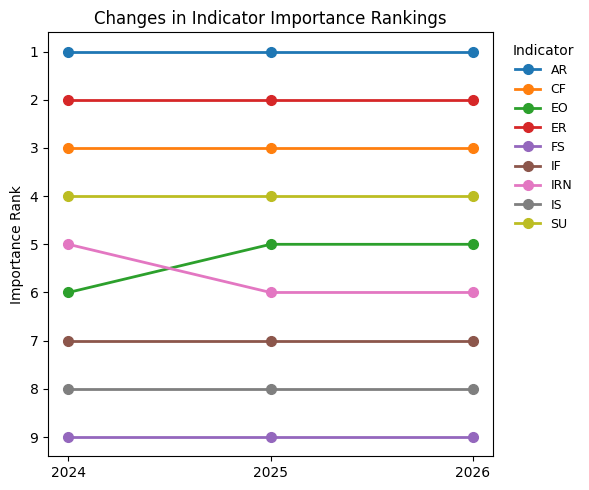

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Shapley importance files
shapley_2024 = pd.read_excel("outputs/QS_Shapley_Importance_24_pipeline.xlsx")
shapley_2025 = pd.read_excel("outputs/QS_Shapley_Importance_25_pipeline.xlsx")
shapley_2026 = pd.read_excel("outputs/QS_Shapley_Importance_26_pipeline.xlsx")

# Add year information
shapley_2024["Year"] = 2024
shapley_2025["Year"] = 2025
shapley_2026["Year"] = 2026

# Combine all years
shapley_history = pd.concat(
    [shapley_2024, shapley_2025, shapley_2026],
    ignore_index=True
)

# Cleaning indicator names
shapley_history["Indicator"] = (
    shapley_history["Indicator"]
    .str.replace("_S_24", "", regex=False)
    .str.replace("_S_25", "", regex=False)
    .str.replace("_S_26", "", regex=False)
)

# Calculating annual importance ranks
shapley_history["Importance Rank"] = (
    shapley_history
    .groupby("Year")["Total Importance (%)"]
    .rank(method="first", ascending=False)
)

# Preparing data for rank chart
shapley_rank_chart = shapley_history.pivot(
    index="Indicator",
    columns="Year",
    values="Importance Rank"
)

# Creating bump chart
plt.figure(figsize=(6, 5))

colors = sns.color_palette("tab10", len(shapley_rank_chart))

for color, (indicator, ranks) in zip(colors, shapley_rank_chart.iterrows()):
    plt.plot(
        shapley_rank_chart.columns,
        ranks.values,
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=7,
        color=color,
        label=indicator
    )

plt.gca().invert_yaxis()

plt.xticks([2024, 2025, 2026])
plt.yticks(range(1, 10))

plt.xlabel("")
plt.ylabel("Importance Rank")
plt.title("Changes in Indicator Importance Rankings")

plt.grid(False)

plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9
)

plt.tight_layout()

plt.savefig("outputs/importance_rankings.png", dpi=300, bbox_inches="tight")

plt.show()

The following analysis compares the average performance of the individual indicators across the three observed years (2024–2026). For each indicator, the mean score was calculated across all universities included in the respective dataset. The grouped bar chart provides an overview of how the average level of each indicator changed over time, allowing the identification of indicators with stable performance patterns as well as those experiencing notable increases or decreases across the three-year period. The accompanying table reports the exact mean values to support a more precise comparison between years.

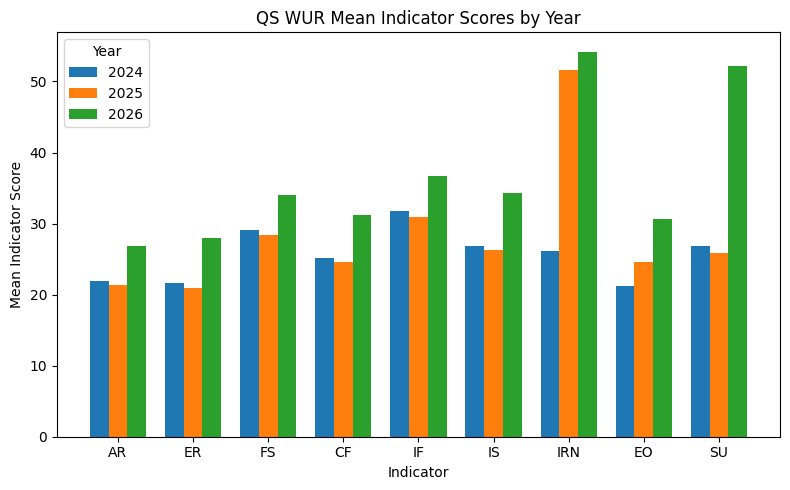

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load fully cleaned final datasets
wur_2024 = pd.read_excel("wur_2024_final_pipeline.xlsx")
wur_2025 = pd.read_excel("wur_2025_final_pipeline.xlsx")
wur_2026 = pd.read_excel("wur_2026_final_pipeline.xlsx")

# Indicators
indicators = ["AR", "ER", "FS", "CF", "IF", "IS", "IRN", "EO", "SU"]

# Calculating means
means_2024 = [wur_2024[f"{ind}_S_24"].mean() for ind in indicators]
means_2025 = [wur_2025[f"{ind}_S_25"].mean() for ind in indicators]
means_2026 = [wur_2026[f"{ind}_S_26"].mean() for ind in indicators]

# Creating grouped bar chart
x = np.arange(len(indicators))
width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(x - width, means_2024, width, label="2024")
plt.bar(x,         means_2025, width, label="2025")
plt.bar(x + width, means_2026, width, label="2026")

plt.xticks(x, indicators)
plt.ylabel("Mean Indicator Score")
plt.xlabel("Indicator")
plt.title("QS WUR Mean Indicator Scores by Year")

plt.legend(title="Year")
plt.tight_layout()

plt.savefig("outputs/mean_indicator_scores_year.png", dpi=300, bbox_inches="tight")
plt.show()

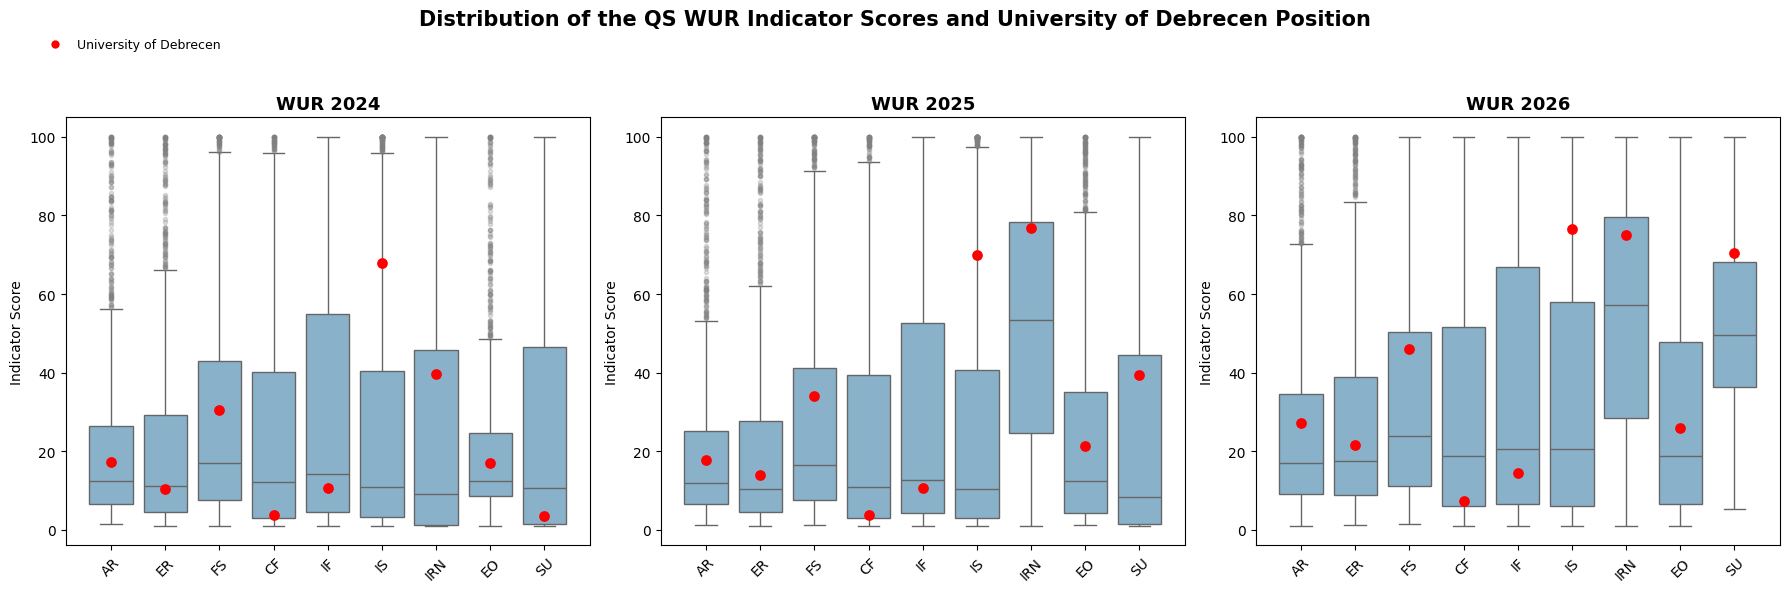

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Load datasets
wur_2024 = pd.read_excel("wur_2024_final_pipeline.xlsx")
wur_2025 = pd.read_excel("wur_2025_final_pipeline.xlsx")
wur_2026 = pd.read_excel("wur_2026_final_pipeline.xlsx")

# Settings
indicators = ["AR", "ER", "FS", "CF", "IF", "IS", "IRN", "EO", "SU"]

datasets = [
    (2024, wur_2024, "24"),
    (2025, wur_2025, "25"),
    (2026, wur_2026, "26")
]

# Figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# Outlier style
flierprops = dict(
    marker="o",
    markerfacecolor="grey",
    markeredgecolor="grey",
    markersize=3,
    alpha=0.25
)

for ax, (year, df, suffix) in zip(axes, datasets):

    # Prepare long format
    plot_data = pd.DataFrame()

    for ind in indicators:
        temp = pd.DataFrame({
            "Indicator": ind,
            "Score": df[f"{ind}_S_{suffix}"]
        })

        plot_data = pd.concat(
            [plot_data, temp],
            ignore_index=True
        )

    # Boxplot
    sns.boxplot(
        data=plot_data,
        x="Indicator",
        y="Score",
        ax=ax,
        color="#7FB3D5",
        showfliers=True,
        flierprops=flierprops
    )

    # University of Debrecen score
    debrecen = df[
        df[f"UNI_{suffix}"]
        .str.contains(
            "Debrecen",
            case=False,
            na=False
        )
    ]

    if not debrecen.empty:

        debrecen_values = [
            debrecen[f"{ind}_S_{suffix}"].iloc[0]
            for ind in indicators
        ]

        ax.scatter(
            range(len(indicators)),
            debrecen_values,
            color="red",
            s=45,
            zorder=5
        )

    # Formatting
    ax.set_title(
        f"WUR {year}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Indicator Score")

    ax.tick_params(
        axis="x",
        rotation=45
    )


# legend and title
legend_element = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="University of Debrecen",
        markerfacecolor="red",
        markersize=7
    )
]

fig.legend(
    handles=legend_element,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.95),
    frameon=True,
    facecolor="white",
    edgecolor="white",
    fontsize=9
)

fig.suptitle(
    "Distribution of the QS WUR Indicator Scores and University of Debrecen Position",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

# Save
plt.savefig(
    "outputs/wur_indicator_boxplots_debrecen_by_year.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [107]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip


In [108]:
# Analysing Regional Performance

# Load fully cleaned final datasets
wur_2024 = pd.read_excel("wur_2024_final_pipeline.xlsx")
wur_2025 = pd.read_excel("wur_2025_final_pipeline.xlsx")
wur_2026 = pd.read_excel("wur_2026_final_pipeline.xlsx")

In [109]:
# Check Coulmns
print("2024 columns:")
print(wur_2024.columns.tolist())

print("\n2025 columns:")
print(wur_2025.columns.tolist())

print("\n2026 columns:")
print(wur_2026.columns.tolist())

2024 columns:
['RANK_24', 'RANK_23', 'UNI_24', 'COUNTRY_CODE_24', 'COUNTRY_24', 'SIZE_24', 'FOCUS_24', 'RES_24', 'STATUS_24', 'AR_S_24', 'AR_R_24', 'ER_S_24', 'ER_R_24', 'FS_S_24', 'FS_R_24', 'CF_S_24', 'CF_R_24', 'IF_S_24', 'IF_R_24', 'IS_S_24', 'IS_R_24', 'IRN_S_24', 'IRN_R_24', 'EO_S_24', 'EO_R_24', 'SU_S_24', 'SU_R_24', 'TOTAL_SCORE_24', 'PRED_TOTAL_SCORE_24']

2025 columns:
['RANK_25', 'RANK_24_25', 'UNI_25', 'COUNTRY_25', 'REGION_25', 'SIZE_25', 'FOCUS_25', 'RES_25', 'STATUS_25', 'AR_S_25', 'AR_R_25', 'ER_S_25', 'ER_R_25', 'FS_S_25', 'FS_R_25', 'CF_S_25', 'CF_R_25', 'IF_S_25', 'IF_R_25', 'IS_S_25', 'IS_R_25', 'IRN_S_25', 'IRN_R_25', 'EO_S_25', 'EO_R_25', 'SU_S_25', 'SU_R_25', 'TOTAL_SCORE_25', 'PRED_TOTAL_SCORE_25']

2026 columns:
['RANK_26', 'RANK_25_26', 'UNI_26', 'COUNTRY_26', 'REGION_26', 'SIZE_26', 'FOCUS_26', 'RES_26', 'STATUS_26', 'AR_S_26', 'AR_R_26', 'ER_S_26', 'ER_R_26', 'FS_S_26', 'FS_R_26', 'CF_S_26', 'CF_R_26', 'IF_S_26', 'IF_R_26', 'IS_S_26', 'IS_R_26', 'ISD_S_26', 

In [110]:
# Check Regional Categories
print("2025 regions:")
print(sorted(wur_2025["REGION_25"].dropna().unique()))

print("\n2026 regions:")
print(sorted(wur_2026["REGION_26"].dropna().unique()))

2025 regions:
['Africa', 'Americas', 'Asia', 'Europe', 'Not Classified', 'Oceania']

2026 regions:
['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']


In [111]:
# Number of universities in each region (2025)
print(wur_2025["REGION_25"].value_counts(dropna=False))

REGION_25
Europe            469
Asia              463
Americas          373
Oceania            46
Africa             30
Not Classified      1
Name: count, dtype: int64


In [112]:
# Universities with 'Not Classified' region
not_classified = wur_2025[wur_2025["REGION_25"] == "Not Classified"]

print(not_classified[["UNI_25", "COUNTRY_25", "REGION_25"]])

                               UNI_25       COUNTRY_25       REGION_25
608  Eastern Mediterranean University  Northern Cyprus  Not Classified


In [113]:
wur_2025.loc[
    wur_2025["COUNTRY_25"] == "Northern Cyprus",
    "REGION_25"
] = "Asia"

In [114]:
countries_2024 = set(wur_2024["COUNTRY_24"].dropna().unique())
countries_2025 = set(wur_2025["COUNTRY_25"].dropna().unique())

print("Countries in 2024 but not in 2025:")
print(sorted(countries_2024 - countries_2025))

print("\nCountries in 2025 but not in 2024:")
print(sorted(countries_2025 - countries_2024))

Countries in 2024 but not in 2025:
['Sudan']

Countries in 2025 but not in 2024:
['Dominican Republic', 'Iceland', 'Kyrgyzstan', 'Luxembourg', 'Northern Cyprus', 'Uzbekistan']


In [115]:
# lookup table from 2025
country_region_lookup = (
    wur_2025[["COUNTRY_25", "REGION_25"]]
    .drop_duplicates()
)

In [116]:
# Rename columns so they match 2024
country_region_lookup = country_region_lookup.rename(
    columns={
        "COUNTRY_25": "COUNTRY_24",
        "REGION_25": "REGION_24"
    }
)

In [117]:
# Check which 2024 countries are missing from the lookup
missing_region_countries = (
    set(wur_2024["COUNTRY_24"].dropna())
    - set(country_region_lookup["COUNTRY_24"])
)

print(missing_region_countries)

{'Sudan'}


In [118]:
sudan_mapping = pd.DataFrame({
    "COUNTRY_24": ["Sudan"],
    "REGION_24": ["Africa"]
})

country_region_lookup = pd.concat(
    [country_region_lookup, sudan_mapping],
    ignore_index=True
)

In [119]:
# Merge region information into 2024
wur_2024 = wur_2024.merge(
    country_region_lookup,
    on="COUNTRY_24",
    how="left"
)

In [120]:
print(wur_2024["REGION_24"].isna().sum())

0


In [121]:
# Compare final region categories
print(sorted(wur_2024["REGION_24"].unique()))
print(sorted(wur_2025["REGION_25"].unique()))
print(sorted(wur_2026["REGION_26"].unique()))

['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']


In [122]:
regions_24 = set(wur_2024["REGION_24"].dropna().unique())
regions_25 = set(wur_2025["REGION_25"].dropna().unique())
regions_26 = set(wur_2026["REGION_26"].dropna().unique())

print("2024 == 2025:", regions_24 == regions_25)
print("2025 == 2026:", regions_25 == regions_26)

print("\nFinal regions:")
print(sorted(regions_24))

2024 == 2025: True
2025 == 2026: True

Final regions:
['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']


In [123]:
print("2024 region counts:")
print(wur_2024["REGION_24"].value_counts())

print("\n2025 region counts:")
print(wur_2025["REGION_25"].value_counts())

print("\n2026 region counts:")
print(wur_2026["REGION_26"].value_counts())

2024 region counts:
REGION_24
Europe      453
Asia        436
Americas    346
Oceania      46
Africa       30
Name: count, dtype: int64

2025 region counts:
REGION_25
Europe      469
Asia        464
Americas    373
Oceania      46
Africa       30
Name: count, dtype: int64

2026 region counts:
REGION_26
Asia        509
Europe      463
Americas    337
Oceania      44
Africa       38
Name: count, dtype: int64


In [124]:
print("Missing regions:")
print("2024:", wur_2024["REGION_24"].isna().sum())
print("2025:", wur_2025["REGION_25"].isna().sum())
print("2026:", wur_2026["REGION_26"].isna().sum())

Missing regions:
2024: 0
2025: 0
2026: 0


In [125]:
print(
    wur_2025[
        wur_2025["UNI_25"] == "Eastern Mediterranean University"
    ][["UNI_25", "COUNTRY_25", "REGION_25"]]
)

                               UNI_25       COUNTRY_25 REGION_25
608  Eastern Mediterranean University  Northern Cyprus      Asia


In [126]:
wur_2024 = wur_2024.rename(columns={"REGION_24": "REGION"})
wur_2025 = wur_2025.rename(columns={"REGION_25": "REGION"})
wur_2026 = wur_2026.rename(columns={"REGION_26": "REGION"})

In [127]:
# Calculating yearly global indicator means
indicator_cols_24 = [
    "AR_S_24", "ER_S_24", "FS_S_24",
    "CF_S_24", "IF_S_24", "IS_S_24",
    "IRN_S_24", "EO_S_24", "SU_S_24"
]

indicator_cols_25 = [
    "AR_S_25", "ER_S_25", "FS_S_25",
    "CF_S_25", "IF_S_25", "IS_S_25",
    "IRN_S_25", "EO_S_25", "SU_S_25"
]

indicator_cols_26 = [
    "AR_S_26", "ER_S_26", "FS_S_26",
    "CF_S_26", "IF_S_26", "IS_S_26",
    "IRN_S_26", "EO_S_26", "SU_S_26"
]

In [128]:
mean_2024 = wur_2024[indicator_cols_24].mean()
mean_2025 = wur_2025[indicator_cols_25].mean()
mean_2026 = wur_2026[indicator_cols_26].mean()

print("2024 indicator means:")
print(mean_2024)

print("\n2025 indicator means:")
print(mean_2025)

print("\n2026 indicator means:")
print(mean_2026)

2024 indicator means:
AR_S_24     21.954767
ER_S_24     21.615256
FS_S_24     29.088711
CF_S_24     25.204882
IF_S_24     31.768421
IS_S_24     26.844241
IRN_S_24    26.109077
EO_S_24     21.165294
SU_S_24     26.837529
dtype: float64

2025 indicator means:
AR_S_25     21.355427
ER_S_25     20.865991
FS_S_25     28.382851
CF_S_25     24.574819
IF_S_25     30.964834
IS_S_25     26.338712
IRN_S_25    51.667438
EO_S_25     24.638857
SU_S_25     25.891172
dtype: float64

2026 indicator means:
AR_S_26     26.856937
ER_S_26     27.961251
FS_S_26     34.030122
CF_S_26     31.153990
IF_S_26     36.670884
IS_S_26     34.248670
IRN_S_26    54.209346
EO_S_26     30.705967
SU_S_26     52.238174
dtype: float64


In [129]:
# Creating Above/Below Mean categories
for indicator in indicator_cols_24:
    wur_2024[indicator + "_category"] = (
        wur_2024[indicator]
        .ge(mean_2024[indicator])
        .map({True: "Above Mean", False: "Below Mean"})
    )

for indicator in indicator_cols_25:
    wur_2025[indicator + "_category"] = (
        wur_2025[indicator]
        .ge(mean_2025[indicator])
        .map({True: "Above Mean", False: "Below Mean"})
    )


for indicator in indicator_cols_26:
    wur_2026[indicator + "_category"] = (
        wur_2026[indicator]
        .ge(mean_2026[indicator])
        .map({True: "Above Mean", False: "Below Mean"})
    )

In [130]:
print(wur_2024["AR_S_24_category"].value_counts())

AR_S_24_category
Below Mean    918
Above Mean    393
Name: count, dtype: int64


In [131]:
# Creating a function to summarize one year
def create_region_indicator_summary(df, year, indicator_cols):
    
    results = []
    
    for indicator in indicator_cols:
        
        category_col = indicator + "_category"
        
        summary = (
            df.groupby(["REGION", category_col])
            .size()
            .reset_index(name="Frequency")
        )
        
        summary["Indicator"] = indicator
        summary["Year"] = year
        
        summary = summary.rename(
            columns={category_col: "Category"}
        )
        
        results.append(summary)
    
    return pd.concat(results, ignore_index=True)

In [132]:
summary_2024 = create_region_indicator_summary(
    wur_2024,
    2024,
    indicator_cols_24
)

summary_2025 = create_region_indicator_summary(
    wur_2025,
    2025,
    indicator_cols_25
)

summary_2026 = create_region_indicator_summary(
    wur_2026,
    2026,
    indicator_cols_26
)

In [133]:
# Combining all years
regional_indicator_summary = pd.concat(
    [
        summary_2024,
        summary_2025,
        summary_2026
    ],
    ignore_index=True
)

regional_indicator_summary.head()

,REGION,Category,Frequency,Indicator,Year
0,Africa,Above Mean,7,AR_S_24,2024
1,Africa,Below Mean,23,AR_S_24,2024
2,Americas,Above Mean,99,AR_S_24,2024
3,Americas,Below Mean,247,AR_S_24,2024
4,Asia,Above Mean,101,AR_S_24,2024


In [134]:
regional_indicator_summary.shape

(270, 5)

In [135]:
regional_indicator_summary[
    (regional_indicator_summary["REGION"] == "Europe") &
    (regional_indicator_summary["Indicator"] == "AR_S_24") &
    (regional_indicator_summary["Year"] == 2024)
]

,REGION,Category,Frequency,Indicator,Year
6,Europe,Above Mean,162,AR_S_24,2024
7,Europe,Below Mean,291,AR_S_24,2024


In [136]:
europe_ar_2024 = regional_indicator_summary[
    (regional_indicator_summary["REGION"] == "Europe") &
    (regional_indicator_summary["Indicator"] == "AR_S_24") &
    (regional_indicator_summary["Year"] == 2024)
]

print(europe_ar_2024["Frequency"].sum())
print(len(wur_2024[wur_2024["REGION"] == "Europe"]))

453
453


In [137]:
regional_indicator_summary.columns

Index(['REGION', 'Category', 'Frequency', 'Indicator', 'Year'], dtype='object')

In [138]:
# Calculate regional percentages
regional_indicator_summary["Region_Total"] = (
    regional_indicator_summary
    .groupby(["Year", "REGION", "Indicator"])["Frequency"]
    .transform("sum")
)

In [139]:
regional_indicator_summary["Percentage"] = (
    regional_indicator_summary["Frequency"] /
    regional_indicator_summary["Region_Total"] * 100
)

In [140]:
regional_indicator_summary[
    (regional_indicator_summary["REGION"] == "Europe") &
    (regional_indicator_summary["Indicator"] == "AR_S_24") &
    (regional_indicator_summary["Year"] == 2024)
]

,REGION,Category,Frequency,Indicator,Year,Region_Total,Percentage
6,Europe,Above Mean,162,AR_S_24,2024,453,35.761589
7,Europe,Below Mean,291,AR_S_24,2024,453,64.238411


In [141]:
check = regional_indicator_summary[
    (regional_indicator_summary["REGION"] == "Europe") &
    (regional_indicator_summary["Indicator"] == "AR_S_24") &
    (regional_indicator_summary["Year"] == 2024)
]

print(check["Percentage"].sum())

100.0


In [142]:
regional_indicator_summary["Percentage"] = (
    regional_indicator_summary["Percentage"]
    .round(1)
)

In [143]:
# Creating clean indicator labels
regional_indicator_summary["Indicator_clean"] = (
    regional_indicator_summary["Indicator"]
    .str.replace("_S_24", "", regex=False)
    .str.replace("_S_25", "", regex=False)
    .str.replace("_S_26", "", regex=False)
)

In [144]:
# Plotting table
plot_data = regional_indicator_summary[
    [
        "REGION",
        "Indicator_clean",
        "Year",
        "Category",
        "Percentage"
    ]
].copy()

plot_data.head()

,REGION,Indicator_clean,Year,Category,Percentage
0,Africa,AR,2024,Above Mean,23.3
1,Africa,AR,2024,Below Mean,76.7
2,Americas,AR,2024,Above Mean,28.6
3,Americas,AR,2024,Below Mean,71.4
4,Asia,AR,2024,Above Mean,23.2


In [145]:
print(plot_data.shape)

(270, 5)


In [146]:
missing = plot_data.isna().sum()

print(missing)

REGION             0
Indicator_clean    0
Year               0
Category           0
Percentage         0
dtype: int64


In [147]:
region_order = [
    "Africa",
    "Americas",
    "Asia",
    "Europe",
    "Oceania"
]

indicator_order = [
    "AR",
    "ER",
    "FS",
    "CF",
    "IF",
    "IS",
    "IRN",
    "EO",
    "SU"
]

In [148]:
import matplotlib.pyplot as plt

# Creating a helper function for one mini bar chart

def draw_mini_chart(ax, data, region, indicator):
    
    subset = data[
        (data["REGION"] == region) &
        (data["Indicator_clean"] == indicator)
    ]
    
    years = [2024, 2025, 2026]
    
    above = (
        subset[subset["Category"] == "Above Mean"]
        .set_index("Year")["Percentage"]
        .reindex(years)
    )
    
    below = (
        subset[subset["Category"] == "Below Mean"]
        .set_index("Year")["Percentage"]
        .reindex(years)
    )
    
    x = range(len(years))
    
    ax.bar(
        x,
        below,
        label="Below Mean"
    )
    
    ax.bar(
        x,
        above,
        bottom=below,
        label="Above Mean"
    )
    
    # formatting
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(
        years,
        fontsize=6
    )
    
    ax.set_yticks([])
    
    # remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

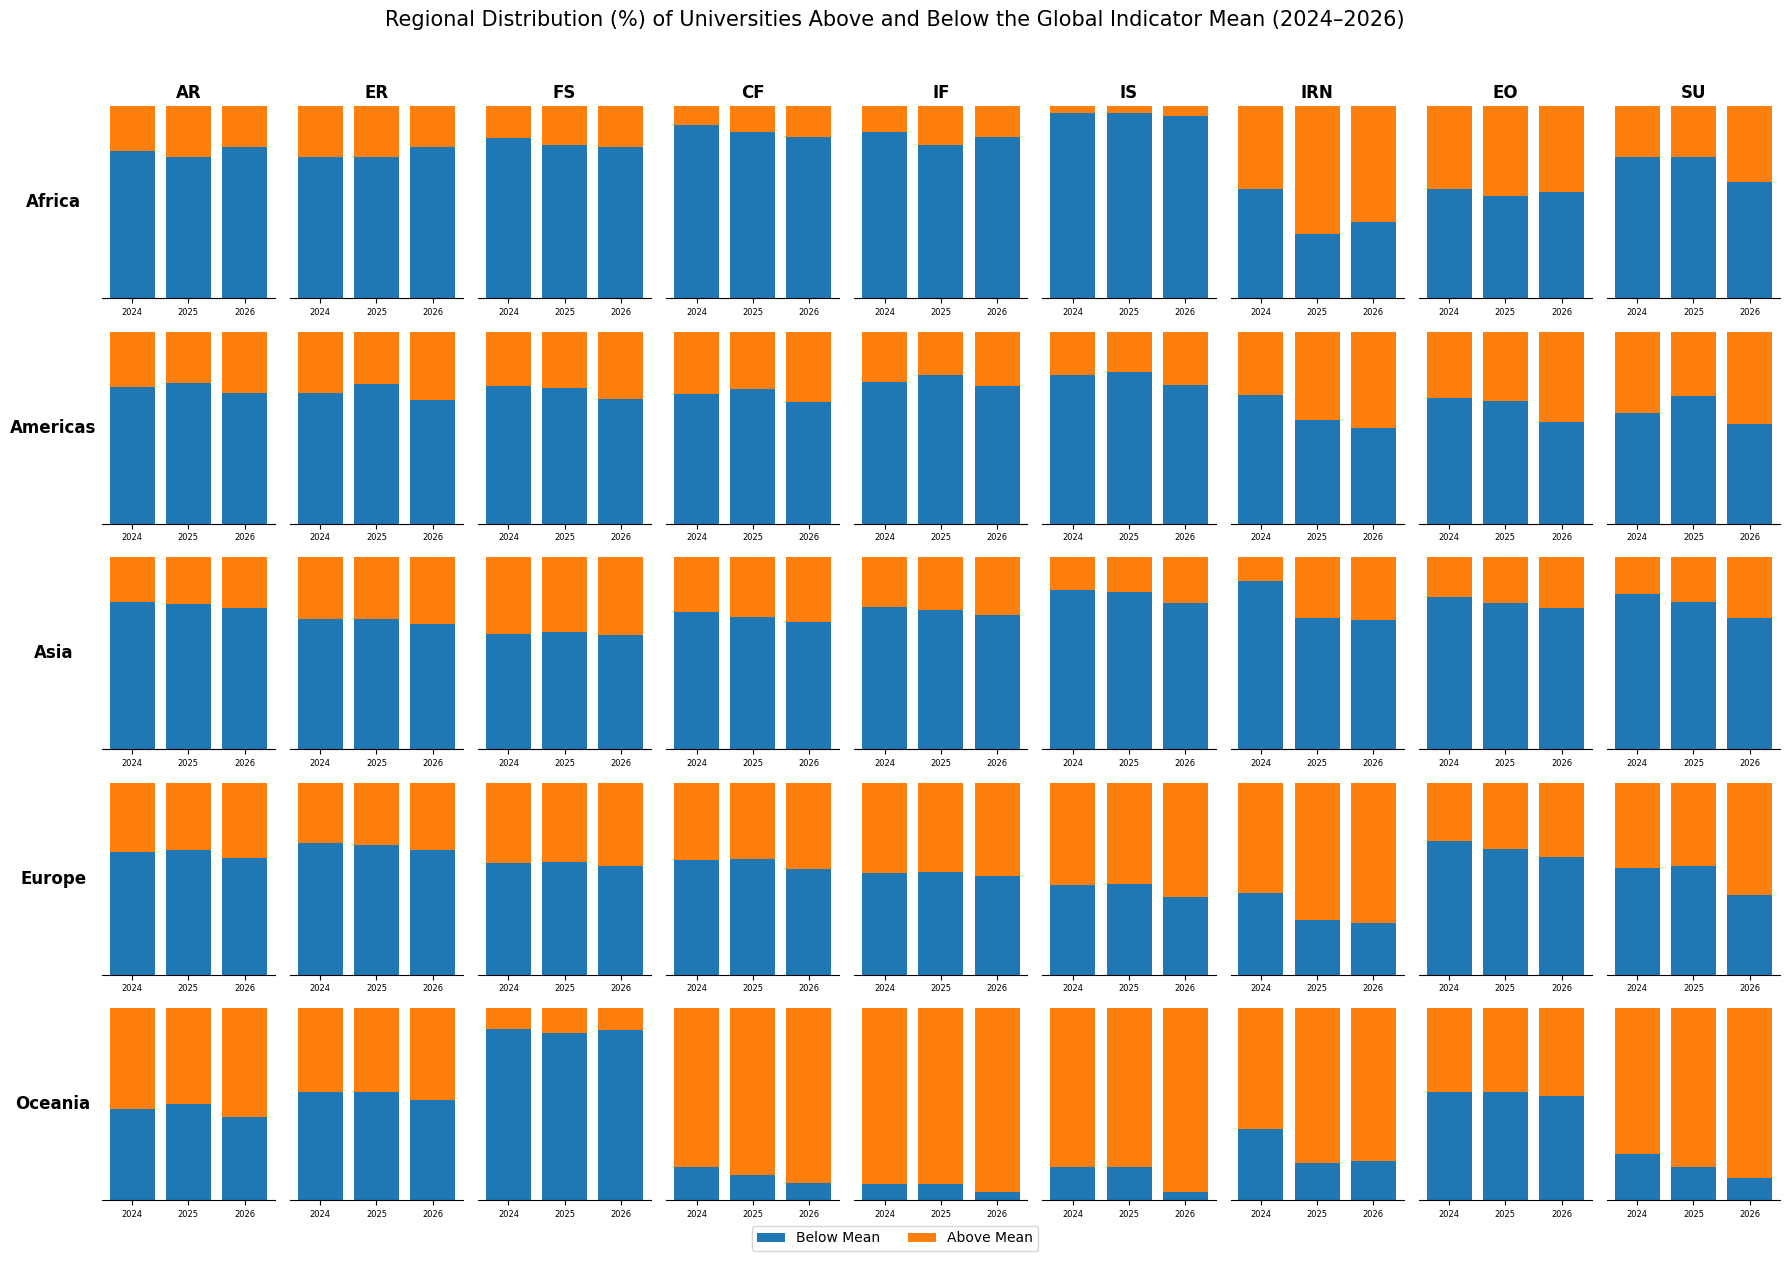

In [149]:
# Creating the grid
fig, axes = plt.subplots(
    len(region_order),
    len(indicator_order),
    figsize=(18, 12),
    sharey=True
)

for i, region in enumerate(region_order):
    for j, indicator in enumerate(indicator_order):
        
        draw_mini_chart(
            axes[i, j],
            plot_data,
            region,
            indicator
        )

for j, indicator in enumerate(indicator_order):
    axes[0, j].set_title(
        indicator,
        fontsize=12,
        fontweight="bold"
    )
    
for i, region in enumerate(region_order):
    axes[i, 0].set_ylabel(
        region,
        fontsize=12,
        fontweight="bold",
        rotation=0,
        labelpad=35,
        va="center"
    )
    
fig.suptitle(
    "Regional Distribution (%) of Universities Above and Below the Global Indicator Mean (2024–2026)",
    fontsize=15,
    y=1.02
)

handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.02)
)
    
plt.tight_layout()

plt.savefig(
    "outputs/regional_indicator_mean_comparison_2024_2026.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [150]:
# Creating a Dasboard for potential decision makers

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown


# Dashboard
title = Markdown(
    """
<div style="text-align:center;">

# QS WUR Indicator Analysis Dashboard

</div>

&nbsp;
"""
)

# Year selector
year_dropdown = widgets.Dropdown(
    options=[2024, 2025, 2026],
    value=2024,
    description="Year:",
    style={"description_width": "initial"}
)

output = widgets.Output()


# DF styling function
def style_dataframe(df):

    return (
        df.style
        .format("{:.2f}")
        .set_table_styles([
            {
                "selector": "table",
                "props": [
                    ("margin-left", "0"),
                    ("margin-right", "auto"),
                    ("border-collapse", "collapse")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1f4e79"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "tr:nth-child(even)",
                "props": [
                    ("background-color", "#f2f7fb")
                ]
            },
            {
                "selector": "tr:nth-child(odd)",
                "props": [
                    ("background-color", "white")
                ]
            }
        ])
    )


# Image display function
def show_image(path, figsize=(8, 6)):

    fig, ax = plt.subplots(
        figsize=figsize
    )

    img = Image.open(path)

    ax.imshow(img)
    ax.axis("off")

    plt.show()

# Dashboard update function
def update_dashboard(change=None):

    with output:

        clear_output(wait=True)

        year = year_dropdown.value
        suffix = str(year)[2:]


        # Dataset Summary
        display(
            Markdown(f"""
## QS WUR ({year}) Dataset Summary

The dataset summary provides a quick overview of the performance and
distribution of QS WUR indicators in the selected year. It helps you
understand the indicator average scores and the range of results 
before interpreting indicator relationships and importance
rankings. You can use this section as the starting point for understanding the
context behind the dashboard results.

Indicators:\n
AR = Academic Reputation; 
ER = Employer Reputation; 
FS = Faculty Student Ratio; 
CF = Citations per Faculty; 
EO = Employment Outcomes; 
IFR = International Faculty Ratio; 
IRN = International Research Network; 
ISR = International Student Ratio; 
SU = Sustainability 

"""
            )
        )


        wur = pd.read_excel(
            f"wur_{year}_final_pipeline.xlsx"
        )


        indicator_cols = [
            f"AR_S_{suffix}",
            f"ER_S_{suffix}",
            f"FS_S_{suffix}",
            f"CF_S_{suffix}",
            f"IF_S_{suffix}",
            f"IS_S_{suffix}",
            f"IRN_S_{suffix}",
            f"EO_S_{suffix}",
            f"SU_S_{suffix}"
        ]


        summary = (
            wur[indicator_cols]
            .describe()
            .loc[
                [
                    "mean",
                    "std",
                    "min",
                    "50%",
                    "max"
                ]
            ]
            .T
        )


        summary.index = [
            "AR",
            "ER",
            "FS",
            "CF",
            "IF",
            "IS",
            "IRN",
            "EO",
            "SU"
        ]


        summary.columns = [
            "Mean",
            "Std. Dev.",
            "Minimum",
            "Median",
            "Maximum"
        ]


        display(
            style_dataframe(summary)
        )


        # Correlation Matrix
        display(
            Markdown(
        """
## Correlation Matrix

The correlation matrix shows the strength and direction of relationships between QS WUR indicators. 
Higher positive values indicate that indicators tend to increase together, while lower values suggest 
weaker relationships. You can use this analysis to identify indicators that move together and to understand 
potential overlaps between different areas of university performance.
"""
            )
        )

        show_image(
            f"outputs/correlation_matrix_wur{year}_pipeline.png",
            figsize=(8, 8)
        )


        # Network Graph
        display(
            Markdown(
        """
## Network Graph

The network graph visualises the relationships between QS WUR indicators and highlights how different areas of 
university performance are connected. 
Stronger connections indicate indicators that tend to change together, 
helping identify clusters of related performance areas and potential opportunities for coordinated improvement.

"""
            )
        )

        show_image(
            f"outputs/network_graph_{year}_pipeline.png",
            figsize=(8, 8)
        )


        # Shapley Importance
        display(
            Markdown(
         """
## Shapley Indicator Importance

The Shapley analysis identifies the relative contribution of each QS WUR indicator to the overall predicted score. It distributes the explanatory power of the model fairly among indicators by considering their contribution across different combinations of factors. Higher importance values indicate indicators that have a stronger influence on the overall score prediction. Use these results to understand which performance areas have the greatest impact and where strategic attention may have the highest potential effect.
"""
            )
        )


        shapley = pd.read_excel(
            f"outputs/QS_Shapley_Importance_{suffix}_pipeline.xlsx"
        )


        shapley = shapley[
            [
                "Indicator",
                "Group",
                "Total Importance (%)",
                "Within Group (%)"
            ]
        ]


        shapley = shapley.sort_values(
            "Total Importance (%)",
            ascending=False
        )


        shapley_style = (
            shapley.style
            .format({
                "Total Importance (%)": "{:.2f}",
                "Within Group (%)": "{:.2f}"
            })
            .set_table_styles([
                {
                    "selector": "table",
                    "props": [
                        ("margin-left", "0"),
                        ("margin-right", "auto"),
                        ("border-collapse", "collapse")
                    ]
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#1f4e79"),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("text-align", "left"),
                        ("padding", "8px")
                    ]
                },
                {
                    "selector": "td",
                    "props": [
                        ("text-align", "left"),
                        ("padding", "8px")
                    ]
                },
                {
                    "selector": "tr:nth-child(even)",
                    "props": [
                        ("background-color", "#f2f7fb")
                    ]
                },
                {
                    "selector": "tr:nth-child(odd)",
                    "props": [
                        ("background-color", "white")
                    ]
                }
            ])
            .hide(axis="index")
        )


        display(
            shapley_style
        )


        # Rankchart   
        display(
            Markdown(
"""
## Overall Indicator Importance Ranking (2024–2026)
The ranking chart shows how the relative importance of QS WUR indicators changes across the three analysed years 
based on the Shapley decomposition results. It highlights shifts in the contribution of each indicator to 
the predicted overall score, making it easier to identify which performance areas have become more or less 
influential over time.

"""
                
            )
        )


        show_image(
            "outputs/importance_rankings.png",
            figsize=(8, 6)
        )

        
        # Mean Indicator Scores by year
        display(
            Markdown(
        """
## Mean Indicator Scores Over Time (2024–2026)

This bar chart shows the mean indicator scores of QS WUR indicators across the three analysed years.
The comparison helps identify indicators with consistent improvement, decline, or variation over time.
Use this overview to understand broader performance trends and determine which indicators have strengthened or may require further attention.
"""
            )
        )


        show_image(
            "outputs/mean_indicator_scores_year.png",
            figsize=(8, 6)
        )
        
        # Regional Above/Below Mean Distribution
        display(
            Markdown(
        """
## Regional Distribution of Universities Above and Below Indicator Mean (2024–2026)

This visualization compares the proportion of universities within each region that perform above or below 
the global mean for each QS WUR indicator across the three analysed years. 
The comparison highlights regional differences in indicator performance patterns and shows whether the 
distribution of universities above the global mean has changed over time.
"""
            )
        )


        show_image(
            "outputs/regional_indicator_mean_comparison_2024_2026.png",
            figsize=(16, 12)
        )

# Connect dropdown
year_dropdown.observe(
    update_dashboard,
    names="value"
)


# Display dashboard
display(title)

display(
    widgets.HBox(
        [year_dropdown],
        layout=widgets.Layout(
            justify_content="flex-start"
        )
    )
)

display(output)

update_dashboard()


<div style="text-align:center;">

# QS WUR Indicator Analysis Dashboard

</div>

&nbsp;


Output()